In [2312]:
import matplotlib.pyplot as plt
import seaborn as sns

# **Phase 1: Explore Data**

In this phase, the main goal was to load the dataset and understand its basic structure, content, and statistics. This step helps us get a clear idea about the data before checking its quality or cleaning it.


In [2313]:
import pandas as pd 
df = pd.read_csv("googleplaystore.csv")
df.shape

(10841, 13)

In [2314]:
df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='str')

In [2315]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [2316]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  str    
 1   Category        10841 non-null  str    
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  str    
 4   Size            10841 non-null  str    
 5   Installs        10841 non-null  str    
 6   Type            10840 non-null  str    
 7   Price           10841 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10841 non-null  str    
 10  Last Updated    10841 non-null  str    
 11  Current Ver     10833 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(1), str(12)
memory usage: 1.1 MB


# **Phase 2: Data Quality Assessment**

In this phase, we checked the quality of the dataset and identified expected issues in each column.  
No actual cleaning was performed, the focus was on detecting problems that may need attention later to handle in the next pahse.

### What was done in this phase:
- **App**: Checked for duplicates.
- **Category**: Noted invalid values or values mistakenly shifted from other columns.  
- **Rating**: Identified missing values and values outside the expected range (0–5).  
- **Reviews, Size, Installs**: Detected non-numeric or irregular formats requiring conversion later.  
- **Type, Price, Content Rating, Genres**: Found missing values, incorrectly shifted entries, and inconsistencies in format.  
- **Last Updated, Current Ver, Android Ver**: Checked for inconsistent formats, missing values, and non-standard text entries.  

This list of data issues is prepared to be addressed in **Phase 3: Data Cleaning**, ensuring a smooth cleaning process 

In [2317]:
# Now, I will test each column individually to identify its issues

In [2318]:
# 1. App
# str --> keep as str 
# 1181 duplicated value 
# No missing values appeared for now --> maybe misleading --> missing values can be written as "unknown" , "none" for example. 

In [2319]:
# Filter rows where the 'App' column contains common missing value keywords
# No such app names found 
missing_keywords = ['unknown', 'none', 'null', 'n/a', '-', 'nan']
missing_apps = df[df['App'].str.lower().isin(missing_keywords)]
missing_apps

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver


In [2320]:
# Count the duplicates in App column (before removing duplicates)
duplicate_apps = df["App"].duplicated().sum()
unique_apps = df['App'].nunique()


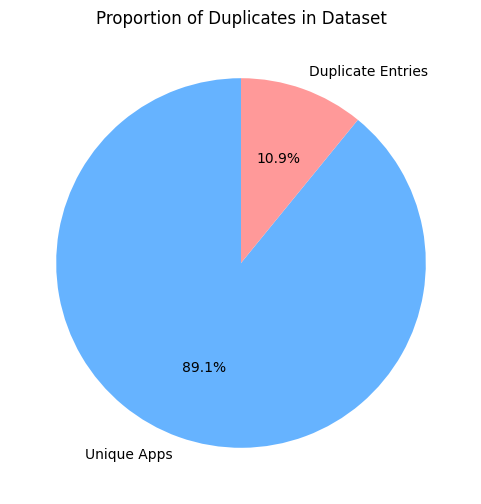

In [2321]:
# Visualization: Duplicate Entries in the Dataset
# Purpose: Show how many duplicate apps exist in the dataset.
# The pie chart compares unique apps with duplicate entries.
labels = ['Unique Apps', 'Duplicate Entries']
sizes = [unique_apps, duplicate_apps]
colors = ['#66b3ff', '#ff9999']
fig, ax = plt.subplots(figsize=(6,6))
ax.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
ax.set_title('Proportion of Duplicates in Dataset')
plt.show()

In [2322]:
# Now i will remove duplicates:
# 1. Sort the dataset by 'Reviews' in descending order
# This ensures that when we remove duplicates, we retain the entry with the most reviews (most popular).
df.sort_values('Reviews', ascending=False, inplace=True)

# 2. Remove duplicate entries based on the 'App' name
# subset=['App']--> Check for duplicates in the 'App' column only
# keep='first': Keep the first occurrence (which corresponds to the highest reviews after sorting)
df.drop_duplicates(subset=['App'], keep='first', inplace=True)

# 3. Reset the index to be sequential
df.reset_index(drop=True, inplace=True)
len(df) # Display the new total count of rows


9660

In [2323]:
# Count the duplicates in App column (after removing duplicates) --> must be 0 
duplicate_apps = df["App"].duplicated().sum()
unique_apps = df['App'].nunique()
duplicate_apps

np.int64(0)

In [2324]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9660 entries, 0 to 9659
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             9660 non-null   str    
 1   Category        9660 non-null   str    
 2   Rating          8197 non-null   float64
 3   Reviews         9660 non-null   str    
 4   Size            9660 non-null   str    
 5   Installs        9660 non-null   str    
 6   Type            9659 non-null   str    
 7   Price           9660 non-null   str    
 8   Content Rating  9659 non-null   str    
 9   Genres          9660 non-null   str    
 10  Last Updated    9660 non-null   str    
 11  Current Ver     9652 non-null   str    
 12  Android Ver     9657 non-null   str    
dtypes: float64(1), str(12)
memory usage: 981.2 KB


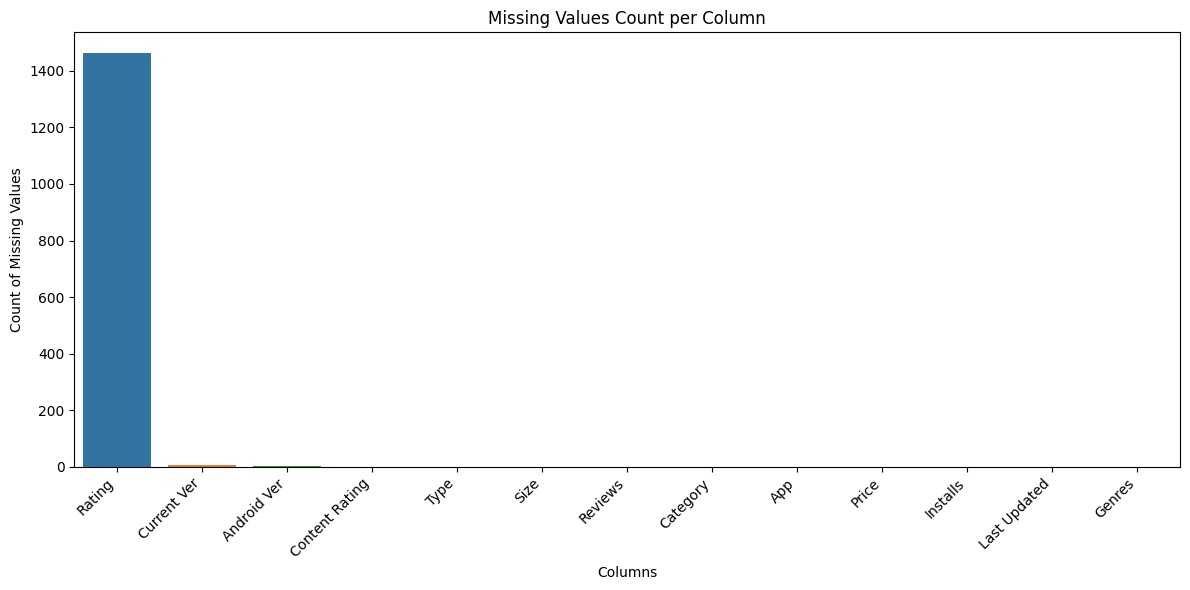

In [2325]:
missing_values = df.isnull().sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(12,6))
sns.barplot(x=missing_values.index,  y=missing_values.values,  hue=missing_values.index , palette='tab10' , ax=ax) 
ax.set_title('Missing Values Count per Column')
ax.set_xlabel('Columns')
ax.set_ylabel('Count of Missing Values')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [2326]:
# 2. Category
# main category of the app
# str --> keep as str 
# no missing values appeared 
# 1.9 --> its actually a rating value --> shifted to category col by mistake  --> (to do in phase 3)

In [2327]:
# Display all unique categories
# Note all are acceptable except '1.9'
df["Category"].unique()

<StringArray>
[             'SPORTS',               'TOOLS',            'SHOPPING',
    'TRAVEL_AND_LOCAL',              'FAMILY',       'VIDEO_PLAYERS',
       'COMMUNICATION',              'COMICS',                'GAME',
             'MEDICAL',       'ENTERTAINMENT',   'AUTO_AND_VEHICLES',
        'PRODUCTIVITY',           'EDUCATION',              'EVENTS',
           'PARENTING',         'PHOTOGRAPHY',           'LIFESTYLE',
            'BUSINESS',             'WEATHER', 'BOOKS_AND_REFERENCE',
     'PERSONALIZATION',  'HEALTH_AND_FITNESS',  'NEWS_AND_MAGAZINES',
              'DATING',             'FINANCE',      'ART_AND_DESIGN',
              'BEAUTY',              'SOCIAL', 'MAPS_AND_NAVIGATION',
      'FOOD_AND_DRINK',  'LIBRARIES_AND_DEMO',      'HOUSE_AND_HOME',
                 '1.9']
Length: 34, dtype: str

In [2328]:
# 3. Rating
# Represents user score of the app (1–5) showing how much users like it.
# float               --> keep as float 
# 1463 missing values --> (to do in phase 3) 
# min = 1 , max = 19 
# mean = 4.17 , median = 4.30
# I know that rating usually is in range 0-5
# Note that max = 19         --> check for rating > 5         --> no other ratings > 5
# Only 1 value is found (19) --> its actually a Reviwes value --> shifted to Rating col by mistake -->  (to do in phase 3) 
df["Rating"].describe()

count    8197.000000
mean        4.174893
std         0.560928
min         1.000000
25%         4.000000
50%         4.300000
75%         4.500000
max        19.000000
Name: Rating, dtype: float64

In [2329]:
# Check for values > 5 other than 19
# No other values  > 5 found 
df[df["Rating"] > 5 ]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
4484,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


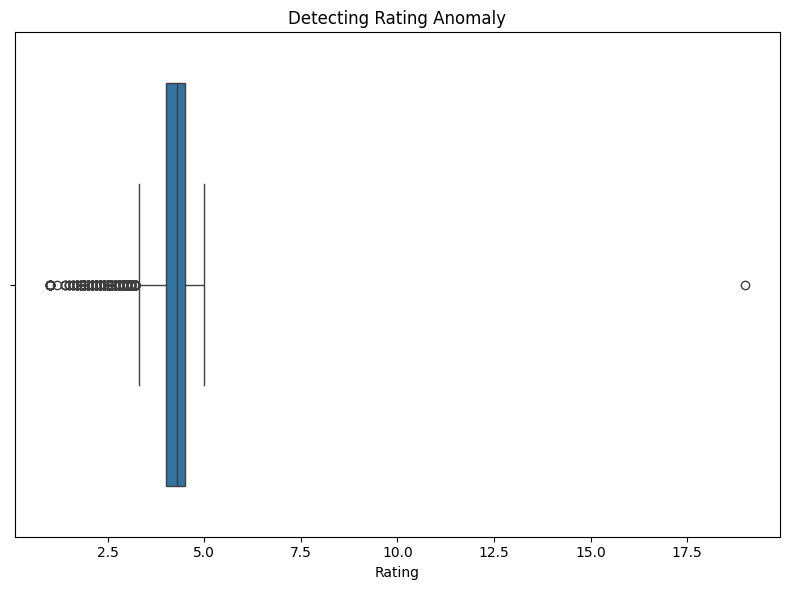

In [2330]:
# Visualization: Rating Distribution & Outlier Detection
# Purpose: Show if there are unusual values in the 'Rating' column.
# The boxplot shows that most ratings are between 3.5 and 4.5.
# However, there is one extreme value (19.0) which is outside the valid range (0–5).
# This indicates a data entry error, so it will be corrected in the next phase.
fig, ax = plt.subplots(figsize=(8,6))
sns.boxplot(x=df['Rating'], ax=ax)
ax.set_title('Detecting Rating Anomaly')
ax.set_xlabel('Rating')
plt.tight_layout()
plt.show()

In [2331]:
# Phase 2: Skipping Visualization for Reviews, Size, Installs, and Price
# The main goal of Phase 2 was to detect data errors.
# Since extreme values in these columns (like viral apps) are valid, 
# There were no errors to find, so we did not visualize them in this phase.

In [2332]:
# 4. Reviews
# Number of user reviews submitted for the app.
# str                                --> convert to int  (to do in phase 3)
# No missing values appeared for now --> maybe misleading bcz the type is str not int 
# Note that out of 9660 row , 9659 is numeric , 1 value is not --> check this value
numeric_reviews =df[df["Reviews"].str.isnumeric()]
len(numeric_reviews)

9659

In [2333]:
# Check for non-numeric value in the "Reviews" column
# Only 1 value is found (3.0M) --> its actually a Size value --> shifted to Reviews col by mistake  -->  (to do in phase 3) 
df[df["Reviews"].str.isnumeric() == False]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
4484,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


In [2334]:
# 5. Size
# The size of the app, it could be stored in  megabytes (M), kilobytes (k)
# No missing values appeared for now --> maybe misleading bcz the type is str not float 
df["Size"].describe()

count                   9660
unique                   462
top       Varies with device
freq                    1227
Name: Size, dtype: object

In [2335]:
# Note the Size col contanis the value 'Varies with device'
df["Size"]

0        31M
1        91k
2        18M
3        33M
4        22M
        ... 
9655     16M
9656    8.0M
9657    2.6M
9658     11M
9659    1.6M
Name: Size, Length: 9660, dtype: str

In [2336]:
# Filter rows where 'Size' contains 'M' (megabytes)
has_M = df[df['Size'].str.contains('M')]
has_M.value_counts(dropna=False).sum()

np.int64(8118)

In [2337]:
# Filter rows where 'Size' contains 'k' (kilobytes)
has_k = df[df['Size'].str.contains('k')]
has_k.value_counts(dropna=False).sum()

np.int64(314)

In [2338]:
# Filter rows where 'Size' contains 'Varies with device'
has_varies_with_device=df[df['Size'].str.contains('Varies with device')]
has_varies_with_device.value_counts(dropna=False).sum()

np.int64(1227)

In [2339]:
# Filter all other rows (not M, k, or 'Varies with device')
# Only 1 row remained --> check its value 
others=df[~df['Size'].str.contains('M') & ~df['Size'].str.contains('k') & ~df['Size'].str.contains('Varies with device') ]
others.value_counts(dropna=False).sum()

np.int64(1)

In [2340]:
# Check the value of the remaining row
# Only 1 value is found (1,000+) --> its actually an Installs value --> shifted to Size col by mistake  -->  (to do in phase 3) 
others

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
4484,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


In [2341]:
# 6. Installs 
# The number of times each app has been installed.
# str --> convert to int             -->   (to do in phase 3)
# No missing values appeared for now --> maybe misleading bcz the type is str not int
# To be able to convert to int       -->  remove symbol appeared in the col ',' & '+'
# How to get sure there is no other symbols in the col ? 
# Instead of manually removing symbols like ',' or '+', we will use Regex to directly clean the column by removing any character that is not a digit.
# This ensures all non-numeric values are handled safely during conversion to integer.
df["Installs"]

0       1,000,000+
1         100,000+
2       1,000,000+
3       1,000,000+
4         500,000+
           ...    
9655          100+
9656          100+
9657          100+
9658            5+
9659           10+
Name: Installs, Length: 9660, dtype: str

In [2342]:
# Filter rows where 'Installs' contains no ',' or '+'
# 2 rows appeared
others=df[~df['Installs'].str.contains(',') & ~df['Installs'].str.contains('+', regex=False) ]
others.value_counts(dropna=False).sum()

np.int64(2)

In [2343]:
# Free value appeared
# It appears that the value "Free" belongs to the 'Type' column 
# but has been mistakenly placed in the 'Installs' column -->  (to do in phase 3)
others

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
4484,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN
9336,Command & Conquer: Rivals,FAMILY,NaN,0,Varies with device,0,NaN,0,Everyone 10+,Strategy,"June 28, 2018",Varies with device,Varies with device


In [2344]:
# 7. Type
# App type based on payment (Free or Paid)
# str --> keep as str 
# 1 missing value (NaN)       --> (to do in phase 3)
# 1 inconsistant category (0) --> its actually a Price value --> shifted to Type col by mistake  --> (to do in phase 3)
df["Type"].value_counts(dropna=False)

Type
Free    8902
Paid     756
0          1
NaN        1
Name: count, dtype: int64

In [2345]:
# Make sure all paid apps have actual price
# No paid apps with price = 0 
df[(df['Type'] == 'Paid') & (df['Price'] == 0)]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver


In [2346]:
# Check for the inconsistant value in the "Types" column
# Only 1 value is found (0)
df[df["Type"]=='0']

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
4484,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


In [2347]:
# 8. Price
# str --> convert to float   (to do in phase 3)
# To be able to convert to int   --> we have to remove values containing currency symbols if any 
# We also found "Everyone" value --> need to be handled
df["Price"].describe()

count     9660
unique      93
top          0
freq      8903
Name: Price, dtype: object

In [2348]:
# Filter rows where 'Price' is numeric
# 8903 row found 
# Convert without problems
numeric_prices =df[df["Price"].str.isnumeric() == True ]
numeric_prices.value_counts(dropna=False).sum()


np.int64(8903)

In [2349]:
# Filter rows where 'Price' is non-numeric
# 757 raw found 
# Handle then convert
non_numeric_prices = df[df['Price'].str.isnumeric() == False]
non_numeric_prices.value_counts(dropna=False).sum()

np.int64(757)

In [2350]:
# Check if all non-numeric prices start with '$'
# All start with '$' except 1 value 'Everyone'
# It appears that the value "Everyone" belongs to the 'Content Rating' column 
# But has been mistakenly placed in the 'Price' column.   (to do in phase 3)
non_numeric_prices[~non_numeric_prices['Price'].str.startswith('$', na=False)]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
4484,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


In [2351]:
# 9. Content Rating
# str --> keep as str
# 1 missing value (NaN) --> its actually a Genres value --> shifted to Content Rating col by mistake  --> (to do in phase 3)
# Categories "Adults only 18+" and "Unrated" are rare compared to other categories,
# This makes class imbalance that may prevent model learning
# So its better to combine them (to do in phase 3)
# Adults only 18+ map to --> Mature 17+  (the nearest category)
# Unrated map to         --> Everyone    (the most common category)
counts =df["Content Rating"].value_counts(dropna=False)

In [2352]:
# Evidence of Class Imbalance:
# The plot shows that the 'Content Rating' categories are not balanced.
# Some categories appear very rarely, such as 'Adults only 18+' and 'Unrated'.
# In Phase 3, these rare categories will be merged to reduce imbalance.

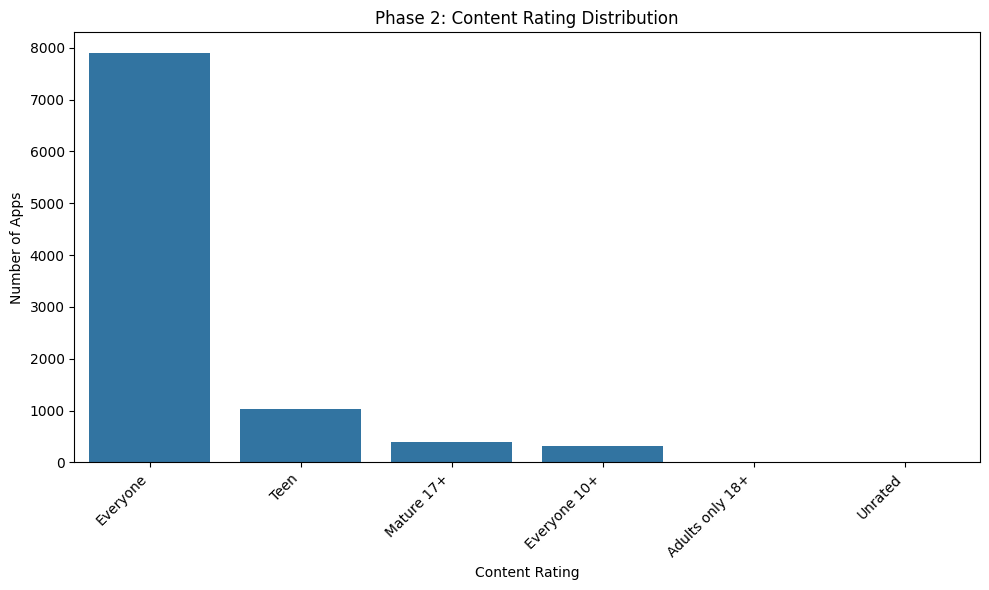

In [2353]:
# Visualization: Content Rating Distribution
# Purpose: Show how apps are distributed across different content ratings.
# - Bar plot displays the number of apps for each content rating category
# - Helps identify which rating groups are most common
fig, ax = plt.subplots(figsize=(10,6))
sns.barplot(x=counts.index, y=counts.values, ax=ax)
ax.set_title('Phase 2: Content Rating Distribution')
ax.set_xlabel('Content Rating')
ax.set_ylabel('Number of Apps')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right') 

plt.tight_layout()
plt.show()

In [2354]:
# 10. Genres
# Genres column has inconsistent formats. Some rows have one genre like (Tools), others have multiple genres separated by ';',
# This column needs cleaning. (to do in phase 3 )
# February 11, 2018 --> its actually a Last Updatedes value --> shifted to Genres col by mistake  --> (to do in phase 3)
df["Genres"].value_counts(dropna=False)

Genres
Tools                          827
Entertainment                  561
Education                      510
Business                       420
Medical                        395
                              ... 
Role Playing;Brain Games         1
Lifestyle;Pretend Play           1
Music & Audio;Music & Video      1
Strategy;Creativity              1
Role Playing;Education           1
Name: count, Length: 120, dtype: int64

In [2355]:
# Look if there are other invalid values like February 11, 2018
# No otherinvalid values found
df[df['Genres'].str.contains(r'\d', na=False)]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
4484,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


In [2356]:
# Filter all rows in 'Genres' that contain multiple genres separated by ';'
# Count how many times each multi-genre combination appears
# Note: The combinations "Education;Education" (50 rows) and "Educational;Education" (41 rows) are the most frequent multi-genre entries. 
# These two genre combinations are very similar and need be merged when cleaning (to do in phase 3)
double_genre_rows = df[df['Genres'].str.contains(';', na=False)]
double_genre_rows['Genres'].value_counts()

Genres
Educational;Education          38
Education;Education            36
Casual;Pretend Play            25
Puzzle;Brain Games             18
Education;Pretend Play         17
                               ..
Role Playing;Brain Games        1
Lifestyle;Pretend Play          1
Music & Audio;Music & Video     1
Strategy;Creativity             1
Role Playing;Education          1
Name: count, Length: 72, dtype: int64

In [2357]:
# Check if there is "Educational" category to map to "Education"  --> to do in phase 3
# There are 37 value with 'Educational' 
genre_Educational=df[df["Genres"] == "Educational"]
len(genre_Educational)


37

In [2358]:
# 11. Last Updatedes
# str --> convert to date  (to do in phase 3)
# No missing values appeared for now --> maybe misleading bcz the type is str not date
df["Last Updated"]

0            May 23, 2018
1       December 17, 2013
2        January 22, 2018
3            June 5, 2018
4          August 6, 2018
              ...        
9655        June 17, 2016
9656        July 28, 2017
9657     December 5, 2017
9658      August 14, 2016
9659        June 14, 2018
Name: Last Updated, Length: 9660, dtype: str

In [2359]:
# 12. Current Ver
# str --> keep as str
# 8 missing values appeared for now --> maybe misleading bcz the type is str not float 
df["Current Ver"]

0           6.5
1           3.2
2           1.4
3           7.1
4        1.28.1
         ...   
9655      1.0.4
9656        1.0
9657      1.1.8
9658    1.0.103
9659        5.0
Name: Current Ver, Length: 9660, dtype: str

In [2360]:
# 8 missing values --> (to do in phase 3)
df["Current Ver"].isna().sum()

np.int64(8)

In [2361]:
# Filter rows where 'Current Ver' is pure number
# Find the number of apps having the 'Current Ver' pure number = 146
pure_num=df[df["Current Ver"].str.isnumeric()]
len(pure_num)

139

In [2362]:
# Identify rows in 'Current Ver' that contain only text (no digits)
# And count how many apps have such pure text version entries
pure_text = (df['Current Ver'].notna() & ~df['Current Ver'].str.contains(r'\d', regex=True))
pure_text_values = df[pure_text]['Current Ver']
pure_text_values.value_counts()

Current Ver
Varies with device            1055
Final                            2
BlueOrange                       1
App copyright                    1
newversion                       1
Natalia Studio Development       1
Human Dx                         1
Copyright                        1
HTTPs                            1
DH-Security Camera               1
Gratis                           1
Public.Heal                      1
KM                               1
opciÃ³n de cerrar                1
closed                           1
Initial                          1
MONEY                            1
Name: count, dtype: int64

In [2363]:
# Filter rows where 'Current Ver' contains ','
# Find the number of apps having the 'Current Ver' contains ',' = 4
# Fix this ',' --> '.'     to do in phase 3
has_coma =df[df['Current Ver'].str.contains(r'\,', na=False)]
has_coma.value_counts(dropna=False).sum()
has_coma

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
1947,M3-X5-X6-M-İ3-İ8 RACİNG 2018,GAME,4.4,596,44M,"100,000+",Free,0,Everyone,Arcade,"February 12, 2017","1,01",4.0 and up
3417,Obbligo o Verità? PRO,GAME,NaN,4,2.9M,100+,Paid,$0.99,Teen,Board,"April 26, 2018","1,01",3.0 and up
4595,BV,COMMUNICATION,5.0,3,1.6M,100+,Free,0,Everyone,Communication,"August 4, 2016","1,01",3.0 and up
8135,C3-C4-PİCASSO-ELYSEE RACİNG,GAME,NaN,12,48M,"1,000+",Free,0,Everyone,Arcade,"February 12, 2017","1,01",4.0 and up


In [2364]:
# I will extract the numeric version into a new column to create a clean feature, while keeping the original text for reference.
# This is why you will not find a purely numeric format in the original Current Ver column

In [2365]:
# Android Ver
# str --> keep as str
# 3 missing values appeared for now --> maybe misleading bcz the type is str not float 
df["Android Ver"]

0         4.1 and up
1         2.2 and up
2         4.3 and up
3         5.0 and up
4         5.0 and up
            ...     
9655      4.0 and up
9656      4.0 and up
9657    4.0.3 and up
9658      4.4 and up
9659      4.0 and up
Name: Android Ver, Length: 9660, dtype: str

In [2366]:
# Filter rows where 'Android Ver' contains 'and up' & find their count = 9467
has_andup =df[df["Android Ver"].str.contains('and up')]
len(has_andup)


8658

In [2367]:
# Filter rows where 'Android Ver' contains 'Varies with device' & find their count = 1362
has_varies_with_device = df[df["Android Ver"].str.contains('Varies with device')]
len(has_varies_with_device)

990

In [2368]:
# Filter rows where 'Android Ver' doesnt contain neither  'Varies with device' nor 'and up' and find their count = 12 
other = df[~(df["Android Ver"].str.contains('and up')) & ~(df["Android Ver"].str.contains('Varies with device'))]
other["Android Ver"].value_counts(dropna=False)

Android Ver
NaN              3
4.0.3 - 7.1.1    2
5.0 - 8.0        2
4.1 - 7.1.1      1
2.2 - 7.1.1      1
5.0 - 6.0        1
7.0 - 7.1.1      1
5.0 - 7.1.1      1
Name: count, dtype: int64

In [2369]:
# I will extract the numeric version into a new column to create a clean feature, while keeping the original text for reference.
# This is why you will not find a purely numeric format in the original Android Ver column

# **Phase 3: Data Cleaning & Transformation**

In this phase, I will perform the cleaning and transformation to fix the issues identified in Phase 2.  

**What was done:**
- **Fixed Data Types:** Converted columns like `Reviews`, `Size`, `Installs`, and `Price` from text to correct numerical formats.  
- **Handled Missing Values:** Used **KNN Imputer** for `Rating`, **Median** for `Size`, and **Simple Imputer** for categorical columns.  
- **Feature Engineering:** Created new useful columns like `Estimated_Revenue`, `Year_Released`, and `Version_Major`.

In [2370]:
# During prev phase, we noticed a problem with this row
# It seems all entries in this row are shifted
# Now i will fix them
df[df["Category"] == '1.9']

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
4484,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


In [2371]:
# Manually fix the row at index 4484 where values are misplaced.
# Set the correct values for each column, including handling missing or shifted entries.
df.loc[4484] = [
    "Life Made WI-Fi Touchscreen Photo Frame",
    None,      # Category
    1.9,       # Rating
    '19.0',      # Reviews
    "3.0M",    # Size
    "1,000+",  # Installs
    "Free",    # Type
    '0',         # Price
    "Everyone",# Content Rating
    None,      # Genres
    "February 11, 2018" , # Last Updated
    "1.0.19",  # Current Ver
    "4.0 and up", # Android Ver
]

In [2372]:
# Display the row after fixing 
df.loc[4484]

App               Life Made WI-Fi Touchscreen Photo Frame
Category                                              NaN
Rating                                                1.9
Reviews                                              19.0
Size                                                 3.0M
Installs                                           1,000+
Type                                                 Free
Price                                                   0
Content Rating                                   Everyone
Genres                                                NaN
Last Updated                            February 11, 2018
Current Ver                                        1.0.19
Android Ver                                    4.0 and up
Name: 4484, dtype: object

In [2373]:
# Now i will start cleaning cols

### **Step 1: Converting to Correct Data Types & Fixing Columns**

| Column        | Current Type | Correct Type | Notes                        |
|---------------|--------------|-------------|-------------------------------|
| Reviews       | str          | int       | Convert numeric text to int   |
| Size          | str          | float       | Handle "M", "k", and "Varies with device" |
| Installs      | str          | int         | Remove symbols like ',' and '+' before conversion |
| Price         | str          | float       | Remove '$' and handle 'Free' values |
| Last Updated  | str          | date        | Convert string dates to datetime format |

In [2374]:
# 1. Reviews
# Any value that cannot be converted will become NaN.
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')
df["Reviews"].dtype

dtype('float64')

In [2375]:
# Convert 'Reviews' col float to int 
df["Reviews"] = df["Reviews"].astype('Int64')
df["Reviews"].dtype

Int64Dtype()

In [2376]:
# After converting to int --> check no nan values appeared
df['Reviews'].isna().sum()

np.int64(0)

In [2377]:
# 2. Size
# We cant convert to float until we deal with the values found in phase2 "M"=MegaByte , "k"=kiloByte , "Varies with device" 
# If the value has "M" remove the M 
# If the value has "k" remove the k and divide by 1024 --> we want the size unit for all values to be in M --> to convert k to M --> divide by 1024
# Else (the value has "Varies with device") set it to None because there is no specific size
# As we handled all the values in the col --> the 'Size' col now is float 
def clean_size (size):
    if 'M' in size:
        return float(size.replace('M',''))
    elif 'k' in size:
        return float(size.replace('k',''))/1024 # convert to mega 
    else: # "varies with device case"
        return None

df["Size"] = df["Size"].apply(clean_size)
df["Size"].dtype

dtype('float64')

In [2378]:
# Note 'M' & 'k' disappeared
# NaN now represents 'Varies with device' before
df['Size']

0       31.000000
1        0.088867
2       18.000000
3       33.000000
4       22.000000
          ...    
9655    16.000000
9656     8.000000
9657     2.600000
9658    11.000000
9659     1.600000
Name: Size, Length: 9660, dtype: float64

In [2379]:
# After converting to int check whether nan values appear 
# 'Size' contains 1227 with the value 'Varies with device'
#  When converting to int , these values become nan
df["Size"].isna().sum()

np.int64(1227)

In [2380]:
# The above method works for converting sizes, but if there are any unexpected symbols combined with number
# (other than 'M', 'k', or "Varies with device"), they will also become NaN, which is not correct. 
# Using isna() allows us to check how many values actually became NaN and detect such issues.
# According to our code every 'Varies with device' should be converted to nan 
# From phase 2 --> count of values containing 'Varies with device' = 1695
# Here check the nan values num --> = 1695
# The count of NaN matches the number of 'Varies with device' entries from Phase 2.
# So the method works as expected

In [2381]:
# 3. Installs 
# We cant convert to float until we deal with the values found in phase2 containing "," , "+" 
# Remove ',' & '+'
# As we handled all the values in the col --> the 'Installs' col now is float 
# Finally convert to int
def clean_Installs(install):
    if ',' in install or '+' in install:
        return float(install.replace(',', '').replace('+', ''))
    else:
        return float(install)
    
df["Installs"] = df["Installs"].apply(clean_Installs)
df["Installs"] = df["Installs"].astype('Int64')

In [2382]:
# Note ',' & '+' disappeared
df["Installs"]

0       1000000
1        100000
2       1000000
3       1000000
4        500000
         ...   
9655        100
9656        100
9657        100
9658          5
9659         10
Name: Installs, Length: 9660, dtype: Int64

In [2383]:
# After converting to int check whether nan values appear 
# No nan values 
df["Installs"].isna().sum()

np.int64(0)

In [2384]:
# The above method works for converting Installs, but if there are any unexpected symbols combined with number
# (other than '+', ','), they will also become NaN, which is not correct. 
# Using isna() allows us to check how many values actually became NaN and detect such issues.
# According to our code nothing should be converted to nan 
# NaN values appeared = 0 
# So the method works as expected

In [2385]:
# 4. Price 
# We cant convert to float until we deal with the values found in phase2 containing "$" 
# Remove '$'
# As we handled all the values in the col --> the 'Installs' col now is float 
def clean_Price(price):
    if '$' in price:
        return float(price.replace('$', ''))
    else:
        return float(price)
    
df["Price"] = df["Price"].apply(clean_Price)
df["Price"].dtype

dtype('float64')

In [2386]:
# After converting to int check whether nan values appear 
# No nan values 
df["Price"].isna().sum()

np.int64(0)

In [2387]:
# The above method works for converting Prices, but if there are any unexpected symbols combined with number
# (other than '$'), they will also become NaN, which is not correct. 
# Using isna() allows us to check how many values actually became NaN and detect such issues.
# According to our code nothing should be converted to nan 
# NaN values appeared = 0 
# So the method works as expected

In [2388]:
# 5. Last Updated 
# Its date --> must be converted to date 
df["Last Updated"] = pd.to_datetime(df["Last Updated"] , errors="coerce")
df["Last Updated"].dtype

dtype('<M8[us]')

In [2389]:
# After converting to date check whether nan values appear 
# No NaN values 
df["Last Updated"].isna().sum()

np.int64(0)

### **Step 2: Handling Outliers**

- **Rating**: Already numeric (checked in Phase 2 using `Rating.describe()`)  
- **Reviews, Size, Installs, Price**: Will check for outliers after converting these columns to numeric in Phase 3 (done) using `describe()`

### 1. Detecting Strategy
| Column       | Min    | Max           | Mean       | Median  | Std        | Notes on Distribution                                   |
| ------------ | ------ | ------------- | ---------- | ------- | ---------- | --------------------------------------------------      |
| **Rating**   | 1      | 5             | 4.19       | 4.30    | 0.51       | Most ratings between 1–5, no obvious outlier            |
| **Reviews**  | 0      | 78,158,310    | 444,388    | 2,094   | 2,927,728  | Highly skewed, extreme high-end values                  |
| **Size**     | 0.0083 | 1000          | 21.62      | 13.0    | 24.80      | Skewed, some extreme high values                        |
| **Installs** | 0      | 1,000,000,000 | 15,464,338 | 100,000 | 85,029,361 | Extremely skewed, high-end outliers                     |
| **Price**    | 0      | 400           | 1.02       | 0       | 15.94      | Highly skewed, most apps free, few expensive outliers   |

Rating values are in natural range 1-5
Reviews, Size, Installs and Price are heavily skewed with high-end outliers.

### 2. Handling Strategy
| Column       | Action / Scaling Approach                               | Reason                                                                  
|------------  |---------------------------------------------------------|-----------------------------------------------------------------------------------------------------------------------------------------------------------------
| **Rating**   | **StandardScaler** can be used | All Rating values are naturally between 1–5 with no outliers, so no action is needed. Standard scaling can be applied
| **Reviews**  | **RobustScaler**                                        | Contains high outliers, but they are natural for this data. No values were removed, RobustScaler is used to reduce their effect during analysis or modeling.
| **Size**     | **RobustScaler**                                        | Some extremely high values exist naturally. Outliers were not removed, RobustScaler reduces their influence.
| **Installs** | **RobustScaler**                                        | Very wide range with extreme high values. These are natural, preserved, and scaled to minimize effect during modeling. 
| **Price**    | **RobustScaler**                                        | Most apps are free (0), but a few expensive apps exist (up to 400). Extreme values are natural, no values were removed, only scaled. 

**Note:**  
- All columns contain outliers, except 'Rating', but for most (Reviews, Size, Installs, Price), the extreme values are expected and natural.   
- Other columns were scaled to reduce the effect of extreme values while preserving the data integrity.


In [2390]:
# Phase 3: Visualizing Reviews, Size, Installs, and Price
# We visualize these columns now to understand their data distribution (skewness).
# This helps decide the best scaling method (RobustScaler or StandardScaler) for model training.

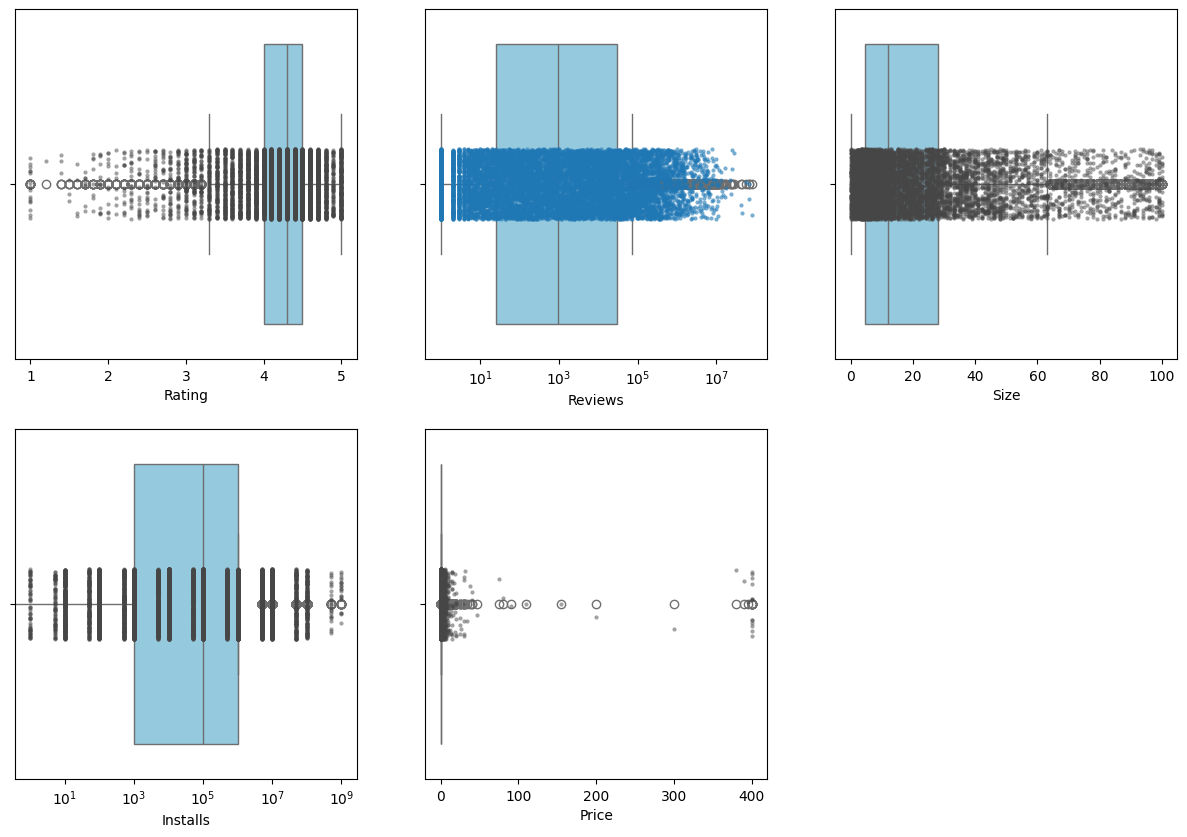

In [ ]:
fig, ax = plt.subplots(2, 3, figsize=(15, 10))

# 1. Rating
# Note: Boxplots identify outliers based on (IQR)
# A valid value like Rating 2.0 might be considered as an outlier if the average is 4.2,
# even if it appears multiple times
# so Outlier does not necessarily mean 'Error' or 'Invalid Data'.
# It just means the value is rare compared to the majority.
# so we dont delete these outliers unless they are logically impossible
# 1 < Rating <= 3.3, Rare values but are real data points
sns.boxplot(x=df['Rating'], ax=ax[0,0], color='skyblue')
sns.stripplot(x=df['Rating'], ax=ax[0,0], color="#474646", alpha=0.5, size=3)

# 2. Reviews
sns.boxplot(x=df['Reviews'] + 1, ax=ax[0,1], color='skyblue')
sns.stripplot(x=df['Reviews'] + 1, ax=ax[0,1], alpha=0.6, size=3)
ax[0,1].set_xscale('log')

# 3. Size
sns.boxplot(x=df['Size'], ax=ax[0,2], color='skyblue')
sns.stripplot(x=df['Size'], ax=ax[0,2], color="#474646", alpha=0.5, size=3)

# 4. Installs
sns.boxplot(x=df['Installs'], ax=ax[1,0], color='skyblue')
sns.stripplot(x=df['Installs'], ax=ax[1,0], color="#474646", alpha=0.5, size=3)
ax[1,0].set_xscale('log')

# 5. Price
sns.boxplot(x=df['Price'], ax=ax[1,1], color='skyblue')
sns.stripplot(x=df['Price'], ax=ax[1,1], color="#474646", alpha=0.5, size=3)


ax[1,2].axis('off')
plt.show()


In [ ]:
# Rating    --> Most apps are rated high (4–4.5), only a few have low scores.
# Reviews   --> A small number of apps get most reviews, most apps have very few.
# Size      --> Most apps are medium-sized (10–40MB), some are very large (up to 100MB).
# Installs  --> Only a few apps have millions/billions of downloads, most have few installs.
# Price     -->  Most apps are free, only a few are paid, and some have very high prices.


In [2392]:
# detect the numeric cols
df[["Rating","Reviews" ,"Size","Installs","Price"]].describe()

,Rating,Reviews,Size,Installs,Price
count,8197.000000,9660.0,8433.000000,9660.0,9660.000000
mean,4.172807,216567.49617,20.390605,7779402.539027,1.099185
std,0.537077,1831304.366029,21.825689,53757306.762141,16.851283
min,1.000000,0.0,0.008301,0.0,0.000000
25%,4.000000,25.0,4.600000,1000.0,0.000000
50%,4.300000,967.0,12.000000,100000.0,0.000000
75%,4.500000,29354.75,28.000000,1000000.0,0.000000
max,5.000000,78158306.0,100.000000,1000000000.0,400.000000


### **step 4: fixing remaining columns**

In [2393]:
# 1. Category 
# Replace underscores with space
df['Category'] = df['Category'].str.replace('_', ' ').str.strip()

In [2394]:
# 2. Content Rating
# Define the mapping dictionary to handle rare categories
map = {'Adults only 18+': 'Mature 17+',  'Unrated': 'Everyone'}
# 3. Apply the mapping to the column
df['Content Rating'] = df['Content Rating'].replace(map)
df['Content Rating'].value_counts()

Content Rating
Everyone        7906
Teen            1036
Mature 17+       396
Everyone 10+     322
Name: count, dtype: int64

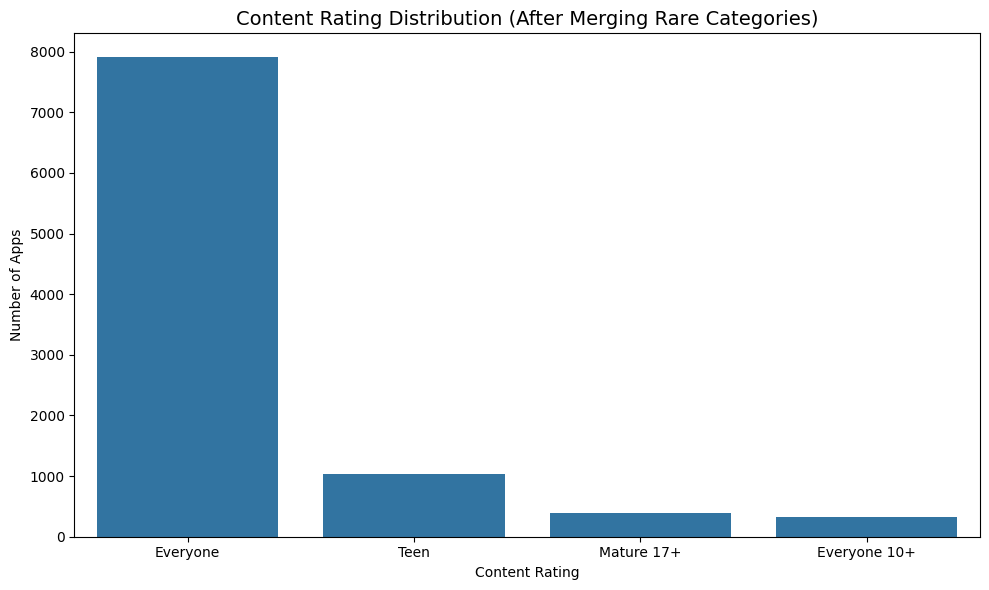

In [2395]:
# Visualization: Content Rating After Cleaning
# Purpose: Validate the categorical cleaning strategy in Step 4.
# This plot confirms that rare categories ('Unrated', 'Adults only 18+') have been successfully merged,
# resulting in a cleaner and more balanced distribution for the model.

fig, ax = plt.subplots(figsize=(10, 6))
sns.countplot(x='Content Rating', data=df,order=df['Content Rating'].value_counts().index,ax=ax)
ax.set_title('Content Rating Distribution (After Merging Rare Categories)', fontsize=14)
ax.set_xlabel('Content Rating')
ax.set_ylabel('Number of Apps')
plt.tight_layout()
plt.show()

In [2396]:
# 4. Genres
# Note Education cantains 510
# In phase 2 we detected this redunduncy Education;Education (36) &  Educational;Education (38)  & Educational (37)
# Map Education;Education    --> Education
# Map Educational;Education  --> Education
# Map Educational            --> Education
# & add their count to Education 549+50+41+37
df["Genres"].value_counts(dropna=False)


Genres
Tools                          827
Entertainment                  561
Education                      510
Business                       420
Medical                        395
                              ... 
Role Playing;Brain Games         1
Lifestyle;Pretend Play           1
Music & Audio;Music & Video      1
Strategy;Creativity              1
Role Playing;Education           1
Name: count, Length: 120, dtype: int64

In [2397]:
# Replace underscores with space
df['Genres'] = df['Genres'].str.replace('_', ' ').str.strip()

In [2398]:
# This function checks for exact redundancy within a genre cell.
# It splits the cell by ';', trims spaces, converts to lowercase,
# And returns True if any part is repeated exactly like 'Education;Education'
# Returns False for unique or non-redundant combinations like 'Educational;Education'
def has_redundancy(genre):
    if pd.isna(genre): 
        return False
    parts = genre.split(';')
    clean_parts = [p.strip().lower() for p in parts]
    return len(parts) != len(set(clean_parts))

In [2399]:
# 36 redundunt value
# The redundancy check confirms that only "Education;Education" (36 rows) exists as exact duplicates in the 'Genres' column. 
# No other exact duplicate were found.
redundant_count = df['Genres'].apply(has_redundancy).sum()
redundant_count

np.int64(36)

In [2400]:
# Fix only specific redundancy cases (all Education-related rows)

df['Genres'] = df['Genres'].replace({
    'Education;Education': 'Education',   # --> count Education;Education   = 36
    'Educational;Education': 'Education', # --> count Educational;Education = 38
    'Educational': 'Education'            # --> count Educational           = 37
})

In [2401]:
# Education count should be 510+(36+38+37) = 621 (checked)
# Note as found now Education count is 621
df["Genres"].value_counts(dropna=False)

Genres
Tools                          827
Education                      621
Entertainment                  561
Business                       420
Medical                        395
                              ... 
Role Playing;Brain Games         1
Lifestyle;Pretend Play           1
Music & Audio;Music & Video      1
Strategy;Creativity              1
Role Playing;Education           1
Name: count, Length: 117, dtype: int64

In [2402]:
# "Education;Education" no such category exists anymore
df[df["Genres"]=="Education;Education"]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver


In [2403]:
# "Educational;Education" no such category exists anymore
df[df["Genres"]=="Educational;Education"]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver


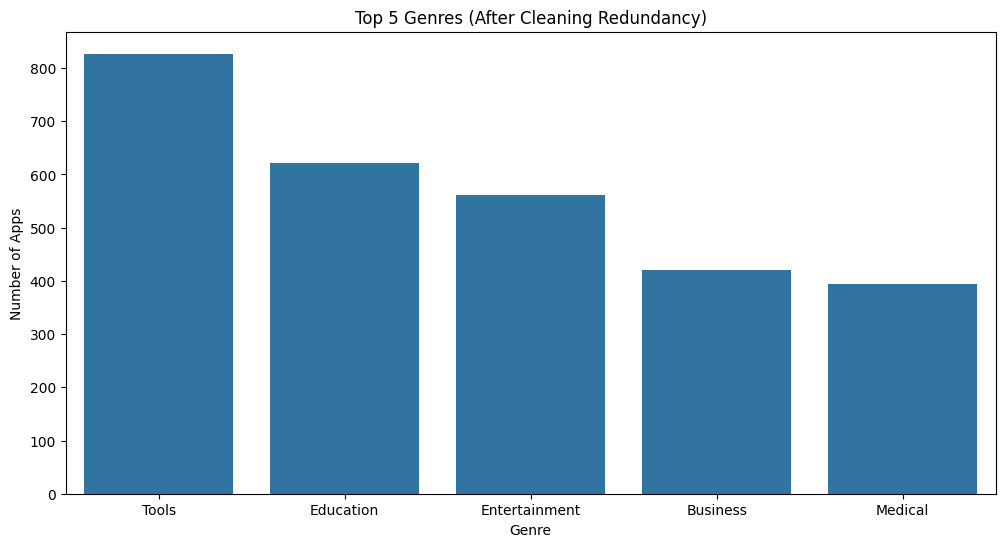

In [2404]:
# Visualization: Top 5 Genres (After Redundancy Fix)
# Purpose: Validate the genre cleaning and redundancy removal.
# This plot confirms that duplicates like 'Education;Education' were merged into 'Education',
# consolidating the genre distribution.
# Note: Before this cleaning step, 'Entertainment' count was larger than 'Education'.
fig, ax = plt.subplots(figsize=(12, 6))
top_5_genres = df['Genres'].value_counts().head(5)
sns.barplot( x=top_5_genres.index,  y=top_5_genres.values,  ax=ax)
ax.set_title('Top 5 Genres (After Cleaning Redundancy)')
ax.set_xlabel('Genre')
ax.set_ylabel('Number of Apps')
plt.show()

In [2405]:
# Current Ver
# Keep the column with minimal cleaning to avoid losing any original information.
# Later, a cleaned version of 'Current Ver' will be extracted for analysis.
# For now, just remove commas from the version numbers to standardize the format.
df["Current Ver"] = df["Current Ver"].str.replace(',', '')

In [2406]:
df[df["Current Ver"].str.contains(',')]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver


In [2407]:
# Android Ver
# Keep the column with minimal cleaning to avoid losing any original information.
# Later, a cleaned version of 'Android Ver' will be extracted for analysis.

### **Step 5: Handling Missing Values**

| Column          | Missing Values | Phase | Imputation Method      |
|-----------------|----------------|-------|----------------------|
| **Rating**      |  1,463  | 1     | KNNImputer           |
| **Type**        | 1              | 2     | SimpleImputer        |
| **Current Ver** | 8              | 2     | manual fill 'unknown'       |
| **Android Ver** | 2              | 2     | manual fill 'unknown'        |
| **Size**        | 1,227          | 3     | SimpleImputer        |
| **Genres**      | 1              | 3     | SimpleImputer      |
| **Category**    | 1              |3      | SimpleImputer

In [2408]:
df.isna().sum()

App                  0
Category             1
Rating            1463
Reviews              0
Size              1227
Installs             0
Type                 1
Price                0
Content Rating       0
Genres               1
Last Updated         0
Current Ver          8
Android Ver          2
dtype: int64

In [2409]:
# 1. Filling the 'Rating' using KNN Imputer
# I assume apps with similar features (like Installs and Reviews) have similar ratings.
# KNN finds these 'neighbors' to fill missing values better than using the average.
# Disadvantage: runtime O(n^2) for KNNImputer
# On our dataset (7k rows), it took 2.1 seconds
# This is reasonable and acceptable given the dataset size
from sklearn.impute import KNNImputer
import numpy as np
# Create KNN imputer
knn_imputer = KNNImputer(n_neighbors=5)
# Apply KNN imputer to a subset of numeric columns related to 'Rating'
cols = ['Rating', 'Reviews', 'Size', 'Installs']
df[cols] = knn_imputer.fit_transform(df[cols])

In [2410]:
df[df["Rating"].isna()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver


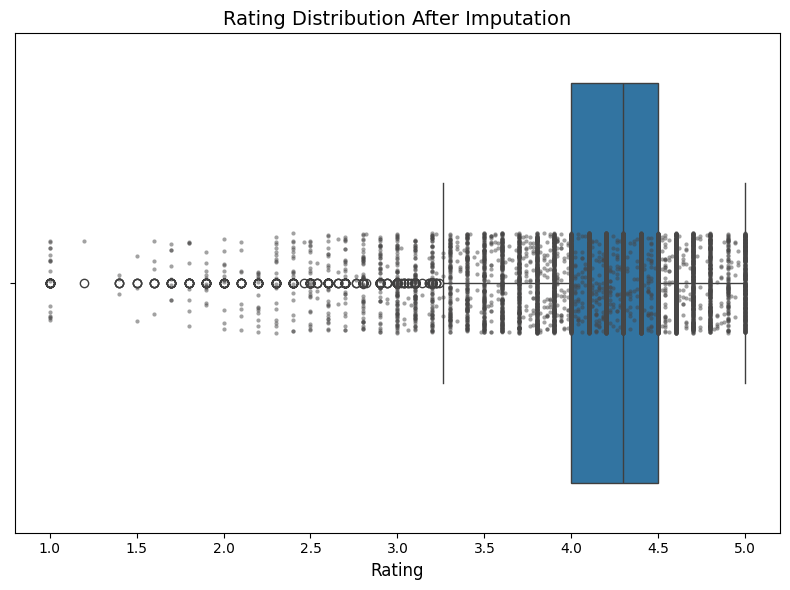

In [2411]:
# Visualization: Rating After KNN Imputation
# Purpose: Verify that missing value imputation did not distort the data.
# The boxplot shows that the rating distribution remains consistent (skewed correctly),
# confirming that the KNN imputer filled values realistically without introducing artifacts.
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(x=df['Rating'], ax=ax)
sns.stripplot(x=df['Rating'], ax=ax, color='#474646', alpha=0.5, size=3)
ax.set_title('Rating Distribution After Imputation', fontsize=14)
ax.set_xlabel('Rating', fontsize=12)
plt.tight_layout()
plt.show()

In [2412]:
# 3. Filling 'Type'& 'Genres' & 'Category'
# 'Type' & 'Genres' & 'Category' have few missings --> fill using SimpleImputer with most_frequent strategy
SimpleImputer_cols = [ 'Type','Genres' , 'Category']
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='most_frequent')
df[SimpleImputer_cols] = imputer.fit_transform(df[SimpleImputer_cols])

In [2413]:
# 4. filling 'Current Ver' & 'Android Ver'
# 'Current Ver' & 'Android Ver' have few missings & represent raw string data kept for reference only.
# Since we will extract the numeric features ('Current_Ver_Cleaned', 'Android_Ver_Cleaned') for the model,
# complex imputation strategies are unnecessary and won't affect the model's accuracy.
# Therefore, we will use simple imputation (filling with 'Unknown') to ensure data consistency 
# and avoid potential errors during string operations, as these columns will be dropped before training.
df[['Current Ver', 'Android Ver']] = df[['Current Ver', 'Android Ver']].fillna('Unknown')

In [2414]:
# 5. filling 'Size' depending on Category median 
# Reason: App size depends on category.
# Games are large, Tools are small.
# Using the category median ensures we assign a realistic size 
# based on the app's type, rather than a misleading global average.
median_per_category = df.groupby('Category')['Size'].agg(lambda x: x.median())
df['Size'] = df['Size'].fillna(df['Category'].map(median_per_category))
# if there are category with all sizes = na --> cant compute median for this category --> fill na with the meadian of the whole 'Size' col
df['Size'] = df['Size'].fillna(df['Size'].median())

### **step 6: feature engineering**

In [2415]:
# 1. 'Year-Released' & 'Month-Released'
# Extract the release year and month from the 'Last Updated' column.
# This creates two new columns:
# - 'Year_Released'  : the year the app was last updated
# - 'Month_Released' : the month the app was last updated
df['Year_Released'] = df['Last Updated'].dt.year
df['Month_Released'] = df['Last Updated'].dt.month

In [2416]:
# 2. Current_Ver_Cleaned
# Extract the numeric portion of the 'Current Ver' column to use in analysis 
# Using regex    -->      (\d+(?:\.\d+)?)  
#   - \d+        -->       matches one or more digits
#   - (?:\.\d+)? --> optionally matches a decimal point followed by digits
# Any text without a number like 'Varies with device', 'Final') will result in NaN
df['Current_Ver_Cleaned'] = df['Current Ver'].str.extract(r'(\d+(?:\.\d+)?)')[0]

# Convert the extracted col into numeric type (float)
# Use errors='coerce' so that any value that cannot be converted becomes NaN
df['Current_Ver_Cleaned'] = pd.to_numeric(df['Current_Ver_Cleaned'], errors='coerce')
df[['Current Ver', 'Current_Ver_Cleaned']].head()

,Current Ver,Current_Ver_Cleaned
0,6.5,6.50
1,3.2,3.20
2,1.4,1.40
3,7.1,7.10
4,1.28.1,1.28


In [2417]:
# In 'Current_Ver_Cleaned' 
# 'Varies with device' becomes nan (1055 value)
# other non numerical values become nan (17 value)
# 8 nan values in  Current_Ver filled with 'unknown'--> when extracted in 'Current_Ver_Cleaned'  --> 8 nan 
# total nan supposed to be 1080
# total nan found 1080
df['Current_Ver_Cleaned'].isna().sum()

np.int64(1080)

In [2418]:
# 3. Android_Ver_Cleaned
# Extract the numeric portion of the 'Android Ver' column to use in analysis 
# Using regex: (\d+(?:\.\d+)?)  
#   - \d+       : matches one or more digits
#   - (?:\.\d+)? : optionally matches a decimal point followed by digits
# Any text without a number like 'Varies with device' will result in NaN
df['Android_Ver_Cleaned'] = df['Android Ver'].str.extract(r'(\d+(?:\.\d+)?)')[0]

# Convert the extracted string numbers into numeric type (float)
# Use errors='coerce' so that any value that cannot be converted becomes NaN
df['Android_Ver_Cleaned'] = pd.to_numeric(df['Android_Ver_Cleaned'], errors='coerce')
df[['Android Ver', 'Android_Ver_Cleaned']].head()

,Android Ver,Android_Ver_Cleaned
0,4.1 and up,4.1
1,2.2 and up,2.2
2,4.3 and up,4.3
3,5.0 and up,5.0
4,5.0 and up,5.0


In [2419]:
# In 'Android_Ver_Cleaned' 
# 'Varies with device' becomes nan (990 value)
# 3 nan values in  Android_Ver_Cleaned 
# 1 filled when we fixed the row where values were shifted --> (become 4 and up)                        --> not nan 
# 2 filled with 'unknown'                                  --> when extracted in 'Current_Ver_Cleaned'  --> 2 nan 
# total nan supposed to be 992
# total nan found 992
df["Android_Ver_Cleaned"].isna().sum()

C:\Users\Dema\AppData\Roaming\Python\Python313\site-packages\IPython\core\displayhook.py:292: UserWarning: Output cache limit (currently 1000 entries) hit.
Flushing oldest 200 entries.
  warn('Output cache limit (currently {sz} entries) hit.\n'


np.int64(992)

In [2420]:
# I filled missing values using the median because it is less affected by extreme values.
# Since app versions change over time, we grouped the data by 'Year_Released' and filled missing values within each year.
# If a certain year had no available data, we used the overall (global) median as a backup to make sure no missing values remain.
cols_to_fix = ['Current_Ver_Cleaned', 'Android_Ver_Cleaned']
for col in cols_to_fix:
    df[col] = df.groupby('Year_Released')[col].transform(lambda x: x.fillna(x.median()))
    global_median = df[col].median()
    df[col]=df[col].fillna(global_median)

In [2421]:
# 4. Extract the major version from Current_Ver_Cleaned & Android_Ver_Cleaned
# Take only the main version number from 'Current_Ver_Cleaned' and 'Android_Ver_Cleaned'.
# This helps the model by giving simpler numbers and removing small details that aren't important,
# so it can learn patterns more easily from the versions.
df['Version_Major'] = df['Current_Ver_Cleaned'].apply(int)
df['Android_Ver_Major'] = df['Android_Ver_Cleaned'].apply(int)

In [2422]:
# 5. Estimated_Revenue 
# Estimate revenue for apps gives approximate estimated earnings
# Multiply Price * Installs * percentage (0.3 here) to estimate revenue
# We assume 30% conversion or revenue factor
df['Estimated_Revenue'] = df['Price'] * df['Installs'] * 0.3
# Display the result
df[['Price',  'Installs',  'Estimated_Revenue']].head(10)

,Price,Installs,Estimated_Revenue
0,0.0,1000000.0,0.0
1,0.0,100000.0,0.0
2,0.0,1000000.0,0.0
3,0.0,1000000.0,0.0
4,0.0,500000.0,0.0
5,0.0,100000.0,0.0
6,0.0,1000000.0,0.0
7,0.0,50000.0,0.0
8,0.0,10000000.0,0.0
9,0.0,100000.0,0.0


In [2423]:
df["Estimated_Revenue"].dtype

dtype('float64')

In [2424]:
# outliers handling :
# min: 0 , max: 20,970,000
# mean: 145,736 , median: 1,797
# std 1.169463e+06
# Big gap btw min, max and mean, median 
# The huge numbers are normal
# No handling stertegy
# Only scaling --> Robust scaling
df['Estimated_Revenue'].describe()

count    9.660000e+03
mean     9.041878e+03
std      2.614836e+05
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      2.097000e+07
Name: Estimated_Revenue, dtype: float64

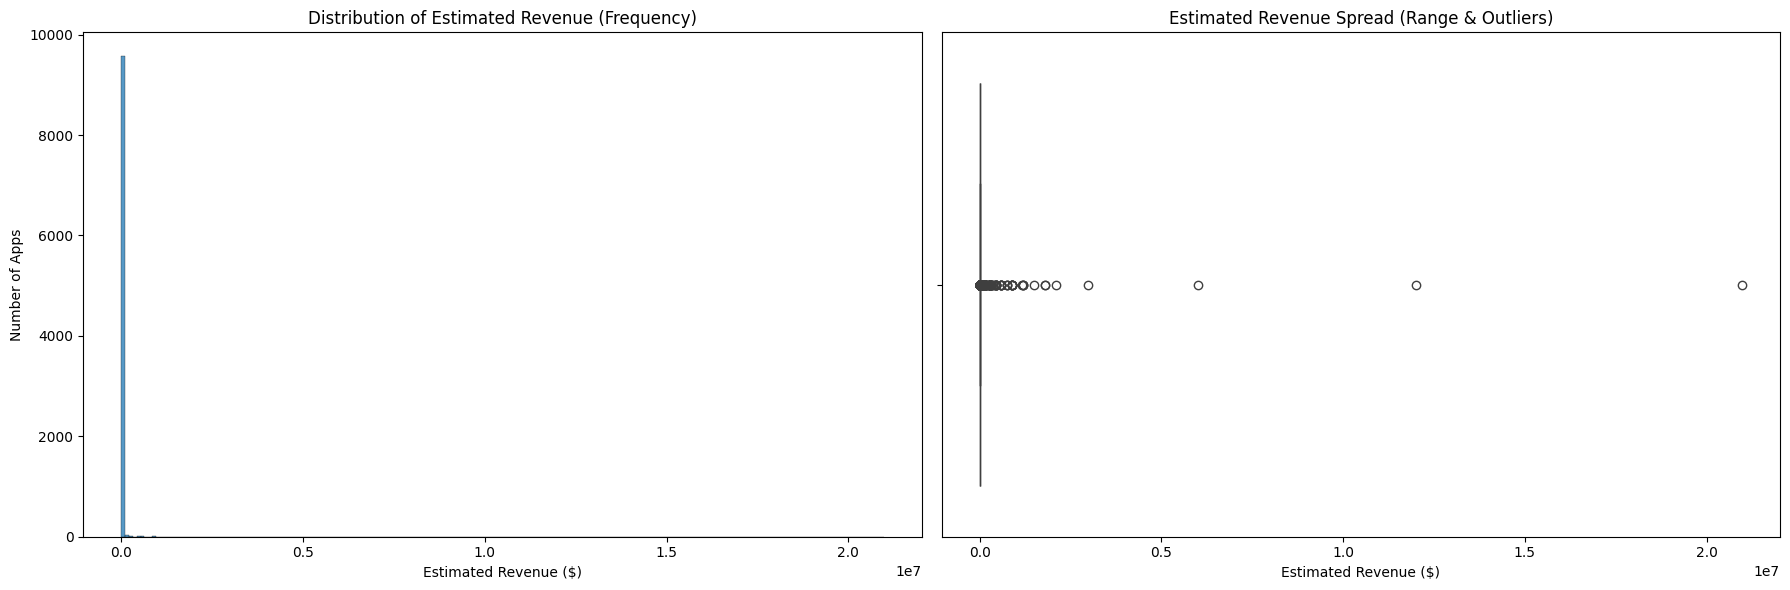

In [2425]:
# Visualization: Estimated Revenue Analysis (Histogram & Boxplot)
# Purpose: Check the new feature and decide if scaling is needed.
# The plots show extreme skewness (many zeros, few high earners),
# so we will use RobustScaler in modeling.

fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Histogram (Frequency)
# Shows the "mass" of the data.
# Most apps have zero revenue.
sns.histplot(ax=ax[0], x=df['Estimated_Revenue'])
ax[0].set_title('Distribution of Estimated Revenue (Frequency)')
ax[0].set_xlabel('Estimated Revenue ($)')
ax[0].set_ylabel('Number of Apps')

# Plot 2: Boxplot (Spread)
# Shows the range and outliers.
# Highlights that few apps earning very high amounts .
sns.boxplot(ax=ax[1], x=df['Estimated_Revenue'])
ax[1].set_title('Estimated Revenue Spread (Range & Outliers)')
ax[1].set_xlabel('Estimated Revenue ($)')

plt.tight_layout()
plt.show()

In [2426]:
# No NaN values found 
df["Estimated_Revenue"].isna().sum()

np.int64(0)

In [2427]:
# 6. Is_High_Rated
# Target Variable Creation
# Purpose: Transform the continuous 'Rating' into a binary classification target.
# Apps with Rating >= 4.0 are considered 'High Rated' (1), others as 'Low Rated' (0).
# This facilitates the use of techniques like SMOTE for handling class imbalance.
df['Is_High_Rated'] = (df['Rating'] >= 4.0).astype(int)
df['Is_High_Rated'].value_counts(dropna=False)


Is_High_Rated
1    7257
0    2403
Name: count, dtype: int64

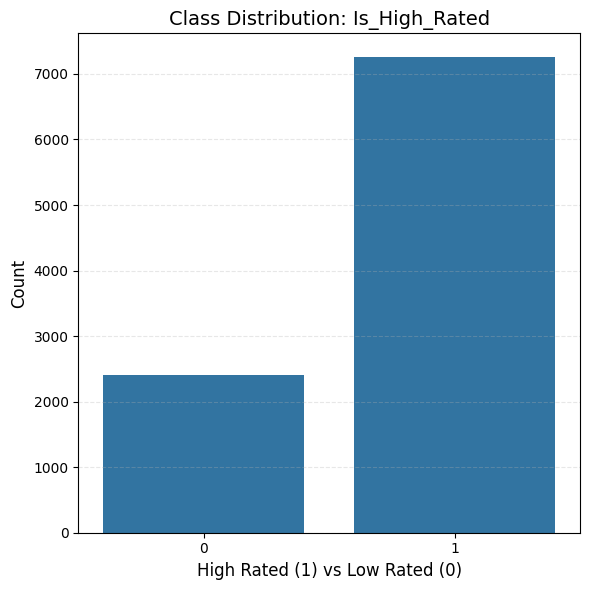

In [2428]:
# Visualization: Distribution of High Rated Apps
# Purpose: Show how many apps are high rated (1) versus low rated (0).
# - Count plot displays the number of apps in each class
# - Helps understand class balance for the 'Is_High_Rated' feature
fig, ax = plt.subplots(figsize=(6, 6))
sns.countplot(  x=df['Is_High_Rated'],  ax=ax)
ax.set_title('Class Distribution: Is_High_Rated', fontsize=14)
ax.set_xlabel('High Rated (1) vs Low Rated (0)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [2429]:
# Reviews & Installs are int not float
df['Reviews'] = df['Reviews'].astype('int64')
df['Installs'] = df['Installs'].astype('int64')

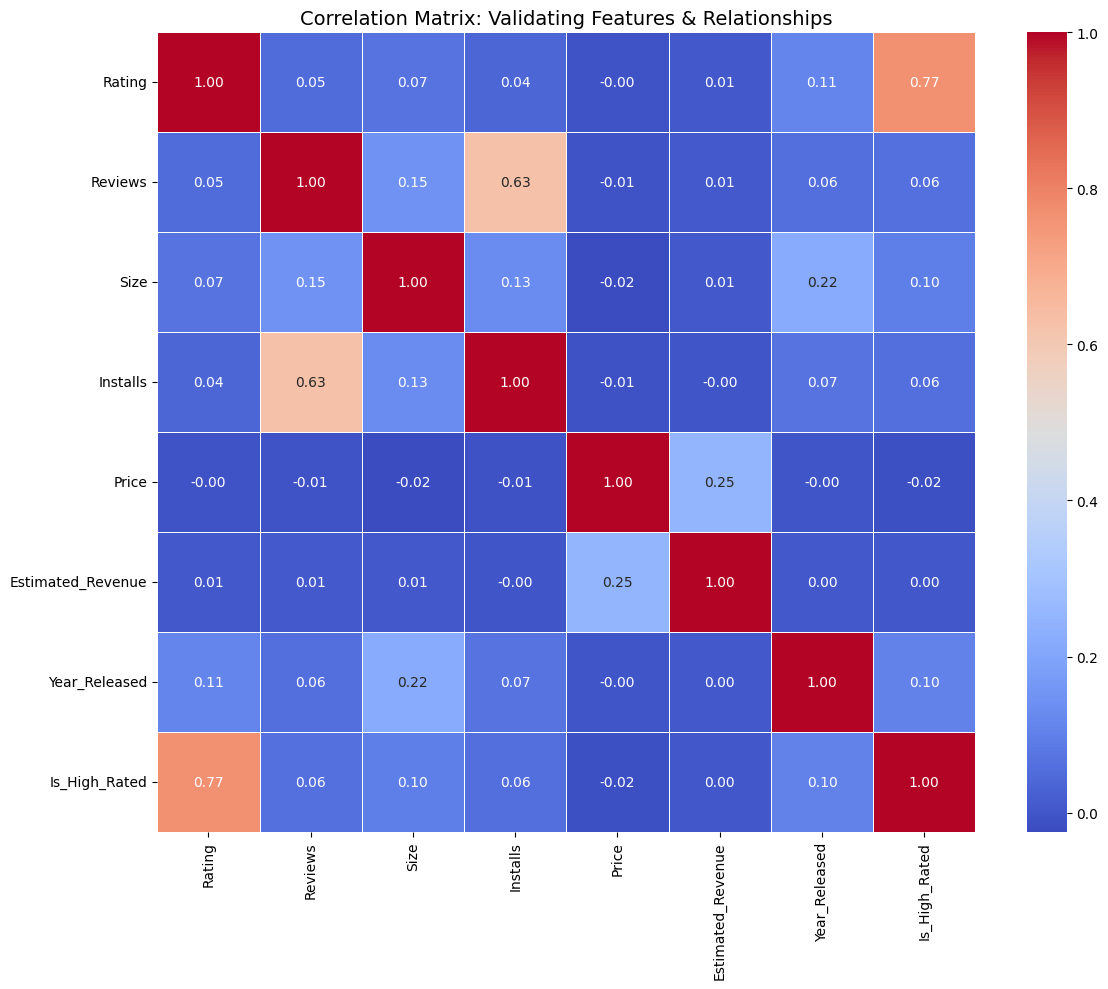

In [2494]:
# Visualization: Feature Correlation Matrix
# Purpose: Final validation of dataset integrity and feature engineering logic.
# This heatmap verifies that new features (Estimated_Revenue, Year_Released) behave logically
# and identifies which features have strong correlations with the target ('Is_High_Rated') for Phase 5.

numeric_cols = ['Rating', 'Reviews', 'Size', 'Installs', 'Price', 'Estimated_Revenue', 'Year_Released', 'Is_High_Rated']
correlation_matrix = df[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix: Validating Features & Relationships', fontsize=14)
plt.tight_layout()
plt.show()

# **Phase 4: Analytical Questions**

In this phase, I will analyze the cleaned data to answer specific business questions.  

**What was done:**
- **Statistical Analysis:** Calculated metrics such as the most expensive app, average sizes, and total revenue.  
- **Visualizations:** Created charts (Bar plots, Heatmaps) to visualize trends and make the data easier to understand.  
- **Insights:** Derived conclusions about user behavior, app categories, and pricing strategies.

#### 1. What is the most expensive app on the Play Store?

In [2431]:
# 1. Find the max price in the dataset
max_price = df['Price'].max()
# 2. Filter the dataset to get the apps with this max price
most_expensive_app = df[df['Price'] == max_price]
# 3. Display the result 
most_expensive_app
# only 1 app displayed "I'm Rich - Trump Edition"

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,...,Current Ver,Android Ver,Year_Released,Month_Released,Current_Ver_Cleaned,Android_Ver_Cleaned,Version_Major,Android_Ver_Major,Estimated_Revenue,Is_High_Rated
4951,I'm Rich - Trump Edition,LIFESTYLE,3.6,275,7.3,10000,Paid,400.0,Everyone,Lifestyle,...,1.0.1,4.1 and up,2018,5,1.0,4.1,1,4,1200000.0,0


In [2432]:
# Analysis:
# The most expensive app is "I am Rich", a joke app with no real functionality.
# It is an extreme price outlier in the dataset.
# This is why using RobustScaler for the Price column is appropriate in the next phase.

C:\Users\Dema\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25105 (\N{CJK UNIFIED IDEOGRAPH-6211}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Dema\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24456 (\N{CJK UNIFIED IDEOGRAPH-5F88}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Dema\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26377 (\N{CJK UNIFIED IDEOGRAPH-6709}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Dema\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 37666 (\N{CJK UNIFIED IDEOGRAPH-9322}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Dema\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170:

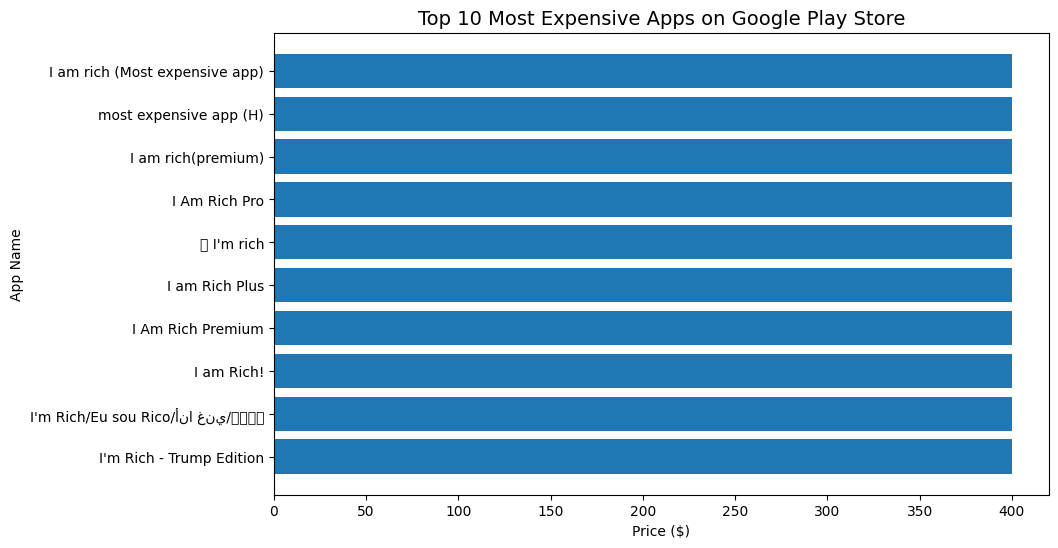

In [2433]:
# Visualization: Top 10 Most Expensive Apps on Google Play Store
# Purpose: Show the apps with the highest prices.
# - Horizontal bar plot displays app names on the y-axis and prices on the x-axis
# - Helps identify which apps are the priciest in the store
top_expensive = df.sort_values(by='Price', ascending=False).head(10)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_expensive['App'], top_expensive['Price'])
ax.set_title('Top 10 Most Expensive Apps on Google Play Store', fontsize=14)
ax.set_xlabel('Price ($)')
ax.set_ylabel('App Name')
plt.show()

In [2434]:
# Note:
# The horizontal bar plot is not very clear because the most expensive app is $400,
# while the other top 9 apps are priced around $399.99.
# The bars appear almost the same length, making it hard to see differences.
# Therefore, a scatter plot is used instead to better visualize these small price differences.

C:\Users\Dema\AppData\Local\Temp\ipykernel_39728\1467232093.py:17: UserWarning: Glyph 25105 (\N{CJK UNIFIED IDEOGRAPH-6211}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Dema\AppData\Local\Temp\ipykernel_39728\1467232093.py:17: UserWarning: Glyph 24456 (\N{CJK UNIFIED IDEOGRAPH-5F88}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Dema\AppData\Local\Temp\ipykernel_39728\1467232093.py:17: UserWarning: Glyph 26377 (\N{CJK UNIFIED IDEOGRAPH-6709}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Dema\AppData\Local\Temp\ipykernel_39728\1467232093.py:17: UserWarning: Glyph 37666 (\N{CJK UNIFIED IDEOGRAPH-9322}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Dema\AppData\Local\Temp\ipykernel_39728\1467232093.py:17: UserWarning: Glyph 128142 (\N{GEM STONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Dema\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2510

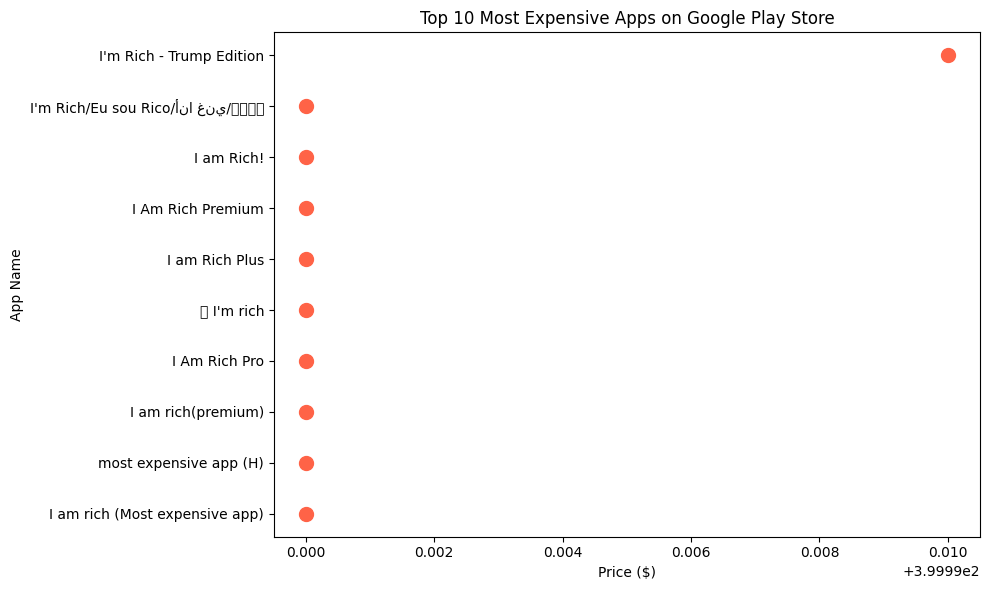

In [2435]:
# Visualization: Top 10 Most Expensive Apps (Scatter Plot)
# Purpose: Show the top 10 priciest apps on Google Play using a scatter plot.
# - Each dot represents an app, positioned by its price on the x-axis
# - App names are shown on the y-axis
# - Helps visualize price distribution and identify outliers
top_expensive = df.sort_values(by='Price', ascending=False).head(10)
fig, ax = plt.subplots(figsize=(10, 6))
apps = top_expensive['App']
prices = top_expensive['Price']
ax.scatter(prices, range(len(apps)), s=100, color='tomato')
ax.set_yticks(range(len(apps)))
ax.set_yticklabels(apps)
ax.invert_yaxis() 
ax.set_title('Top 10 Most Expensive Apps on Google Play Store')
ax.set_xlabel('Price ($)')
ax.set_ylabel('App Name')
plt.tight_layout()
plt.show()

#### 2. Which genre has the highest number of apps? 

In [2436]:
# Count the frequency of each genre (including missing values) and display the top ones
df["Genres"].value_counts(dropna=False)

Genres
Tools                          828
Education                      621
Entertainment                  561
Business                       420
Medical                        395
                              ... 
Role Playing;Brain Games         1
Lifestyle;Pretend Play           1
Music & Audio;Music & Video      1
Strategy;Creativity              1
Role Playing;Education           1
Name: count, Length: 116, dtype: int64

In [2437]:
# Analysis:
# "Tools" is the most common genre.
# This indicates that developers often create utility apps, likely because they are in high demand.

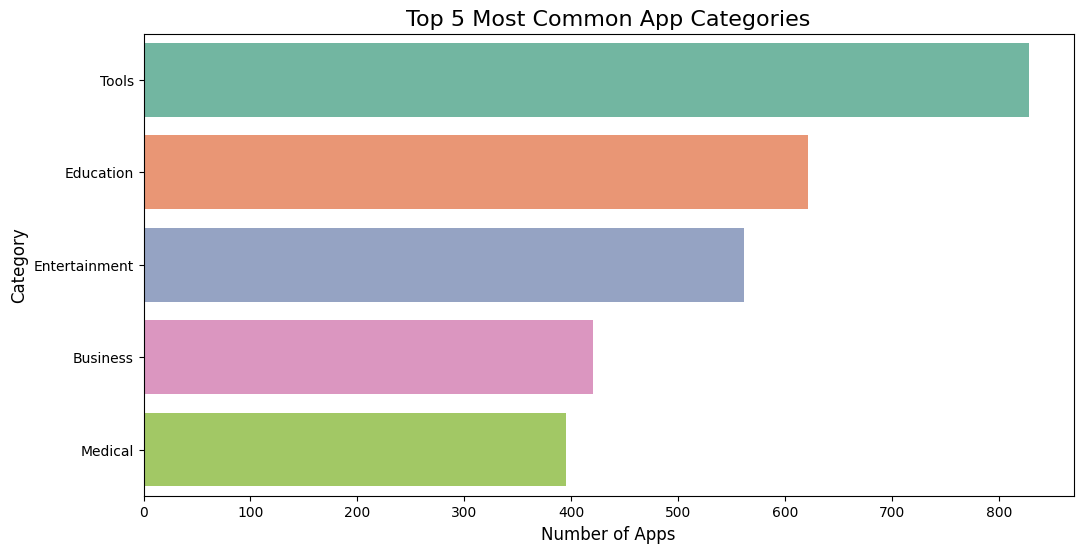

In [2438]:
# Visualization: Top 5 Most Common App Genres
# Purpose: Show which app genres have the most apps in the dataset.
# - Bar plot displays the top 5 genres and their counts
# - Helps identify the most popular categories among developers
top_5_categories = df['Genres'].value_counts().head(5)
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot( x=top_5_categories.values,  y=top_5_categories.index,  ax=ax, palette='Set2', hue=top_5_categories.index,  dodge=False,              legend=False         )
ax.set_title('Top 5 Most Common App Categories', fontsize=16)
ax.set_xlabel('Number of Apps', fontsize=12)
ax.set_ylabel('Category', fontsize=12)
plt.show()

#### 3. What is the average size of free vs. paid apps?

In [2439]:
# Calculate the average app size for each Type (Free vs Paid)
avg_size = df.groupby("Type")["Size"].mean()
avg_size

Type
Free    21.624775
Paid    19.261052
Name: Size, dtype: float64

In [2440]:
# Analysis:
# Free apps are slightly larger on average than Paid apps.
# This is likely because free apps include ads or extra content, which increases their size.

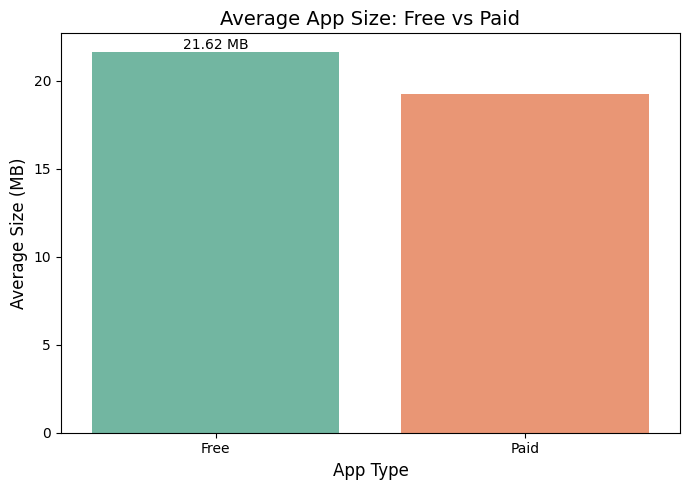

In [2441]:
# Visualization: Average App Size for Free vs Paid Apps
# Purpose: Compare the average file size of Free and Paid apps.
# - Bar plot shows average size in MB for each app type
# - Labels on bars display the exact average size
# - Helps understand if Paid apps are generally larger than Free apps
fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot( x=avg_size.index, y=avg_size.values,  ax=ax, palette='Set2', hue=avg_size.index, dodge=False,         legend=False        )
ax.bar_label(ax.containers[0], fmt='%.2f MB')
ax.set_title('Average App Size: Free vs Paid', fontsize=14)
ax.set_xlabel('App Type', fontsize=12)
ax.set_ylabel('Average Size (MB)', fontsize=12)
plt.tight_layout()
plt.show()

#### 4. What are the top 5 most expensive apps with a perfect rating (5)?

In [2442]:
# Filter for 5-perfect apps and show the top 5 most expensive ones.
perfect_apps = df[df["Rating"] == 5 ]
top_5_expensive_perfect = perfect_apps.sort_values(by="Price", ascending=False).head(5)
top_5_expensive_perfect.head(5)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,...,Current Ver,Android Ver,Year_Released,Month_Released,Current_Ver_Cleaned,Android_Ver_Cleaned,Version_Major,Android_Ver_Major,Estimated_Revenue,Is_High_Rated
9477,Eu Sou Rico,FINANCE,5.0,0,1.4,0,Paid,394.99,Everyone,Finance,...,1.0,4.0.3 and up,2018,7,1.0,4.0,1,4,0.000,1
9577,EP Cook Book,MEDICAL,5.0,0,3.2,0,Paid,200.00,Everyone,Medical,...,1.0,3.0 and up,2015,7,1.0,3.0,1,3,0.000,1
9308,cronometra-br,PRODUCTIVITY,5.0,0,5.4,0,Paid,154.99,Everyone,Productivity,...,1.0.0,4.1 and up,2017,11,1.0,4.1,1,4,0.000,1
9371,BP Fitness Lead Scanner,EVENTS,5.0,0,6.7,1,Paid,109.99,Everyone,Events,...,0.0.1,4.1 and up,2017,8,0.0,4.1,0,4,32.997,1
9445,Eu sou Rico,FINANCE,5.0,0,2.6,0,Paid,30.99,Everyone,Finance,...,1.0,4.0 and up,2018,1,1.0,4.0,1,4,0.000,1


In [2443]:
# Analysis:
# The most expensive app is "Eu Sou Rico" at $395.
# These are professional apps (Finance, Medical), so the high price is expected.
# They have few users and reviews, which helps them maintain a perfect 5.0 rating.

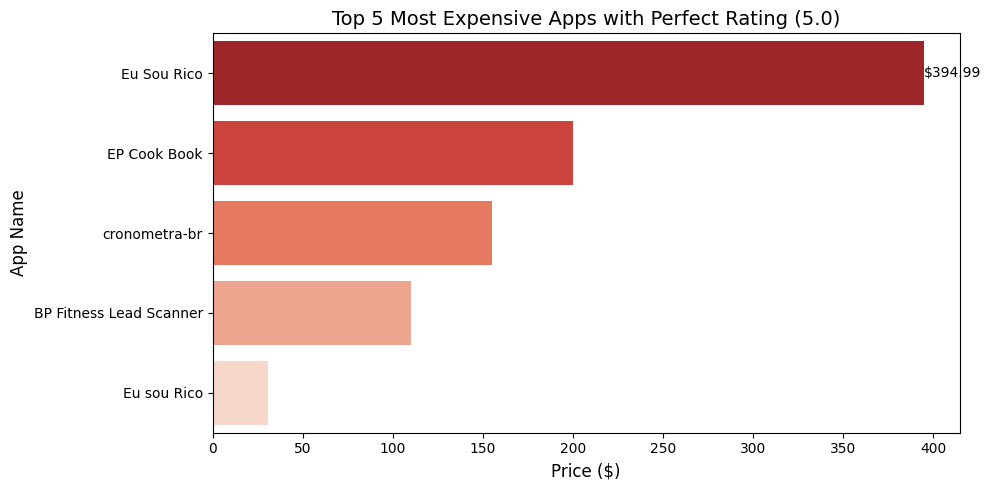

In [2444]:
# Visualization: Top 5 Most Expensive Apps with Perfect Rating
# Purpose: Show the most expensive apps that have a perfect 5.0 rating.
# - Bar plot displays app names on the y-axis and their prices on the x-axis
# - Helps identify high-value apps that users rate highly
# - Labels on bars show exact prices for clarity
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot( x='Price', y='App', data=top_5_expensive_perfect, ax=ax, palette='Reds_r', hue=top_5_expensive_perfect['App'],  dodge=False, legend=False)                          
ax.bar_label(ax.containers[0], fmt='$%.2f')
ax.set_title('Top 5 Most Expensive Apps with Perfect Rating (5.0)', fontsize=14)
ax.set_xlabel('Price ($)', fontsize=12)
ax.set_ylabel('App Name', fontsize=12)
plt.tight_layout()
plt.show()

#### 5. How many apps have received more than 50,000 reviews?

In [2445]:
# Counts how many apps have more than 50,000 reviews
most_reviews = df[df["Reviews"]>50000]
most_reviews_count=len(most_reviews)

normal_reviews = df[df["Reviews"]<=50000]
normal_reviews_count=len(normal_reviews)


In [2446]:
# Analysis:
# Only about 20% of apps have more than 50,000 reviews.
# This shows that most apps receive relatively few reviews.

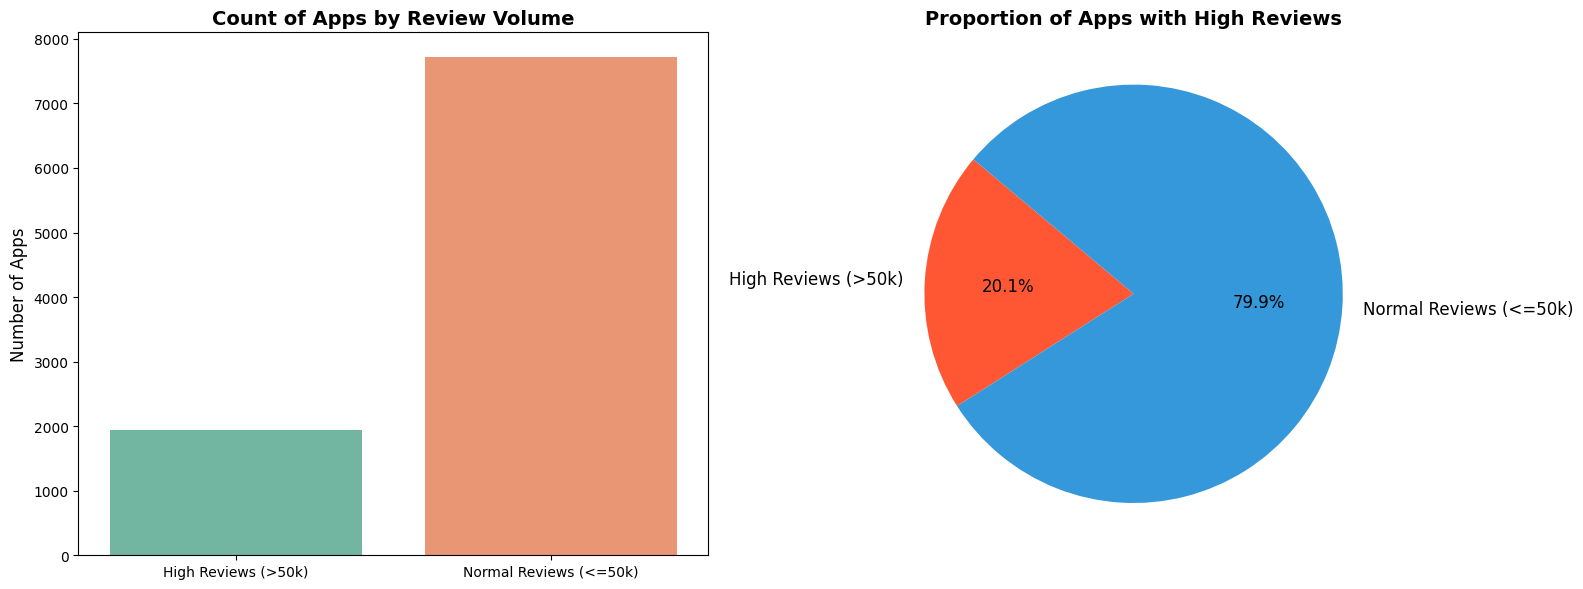

In [2447]:
# Visualization: Apps with High vs Normal Review Counts
# Purpose: Show how many apps have more than 50,000 reviews.
# - Left: Bar plot showing counts of apps with high (>50k) and normal (<=50k) reviews
# - Right: Pie chart showing the proportion of apps in each review category
# - Helps identify how common highly reviewed apps are in the dataset

labels = ['High Reviews (>50k)', 'Normal Reviews (<=50k)']
counts = [most_reviews_count, normal_reviews_count]
colors = ['#FF5733', '#3498DB']
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x=labels, y=counts, ax=ax[0], palette='Set2' , hue=labels,     dodge=False,legend=False)
ax[0].set_title('Count of Apps by Review Volume', fontsize=14, fontweight='bold')
ax[0].set_ylabel('Number of Apps', fontsize=12)
ax[0].set_xlabel('')

ax[1].pie(counts, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140, textprops={'fontsize': 12})
ax[1].set_title('Proportion of Apps with High Reviews', fontsize=14, fontweight='bold')


plt.tight_layout()
plt.show()

In [2448]:
# Create Install_Level categories based on number of installs
# - Specialized (<10k), Popular (10k-1M), Viral (1M-10M), Ultra (>10M)
# This categorization will be used for analyzing trends in:
#   - Average app size
#   - Average app price
#   - App rating
# across different install levels in the next questions.
df_paid = df[df['Type'] == 'Paid']
bins = [0, 10000, 1000000, 10000000, 10000000000]
labels = ['Niche (<10k)', 'Popular (10k-1M)', 'Viral (1M-10M)', 'Ultra (>10M)']
df['Install_Level'] = pd.cut(df['Installs'], bins=bins, labels=labels)

#### 6. What is the average price of apps grouped by genre and number of installs?

In [2449]:
# Calculate the avg price of paid apps grouped by Genre and number of Installs
df_paid = df[df['Type'] == 'Paid']
df_paid.groupby(["Genres","Installs"])["Price"].mean()

Genres   Installs
Action   50          1.990000
         100         2.740000
         1000        1.490000
         10000       5.990000
         50000       2.990000
                       ...   
Weather  500         2.490000
         1000        6.990000
         10000       2.990000
         100000      3.823333
         500000      5.990000
Name: Price, Length: 300, dtype: float64

In [2450]:
# Analysis:
# App prices strongly depend on genre and install level.
# More installs do not always mean a higher price.
# Free apps often have the most downloads, so high install counts can correspond to low or zero price.
# Expensive apps usually target specialized markets, so fewer people buy them.

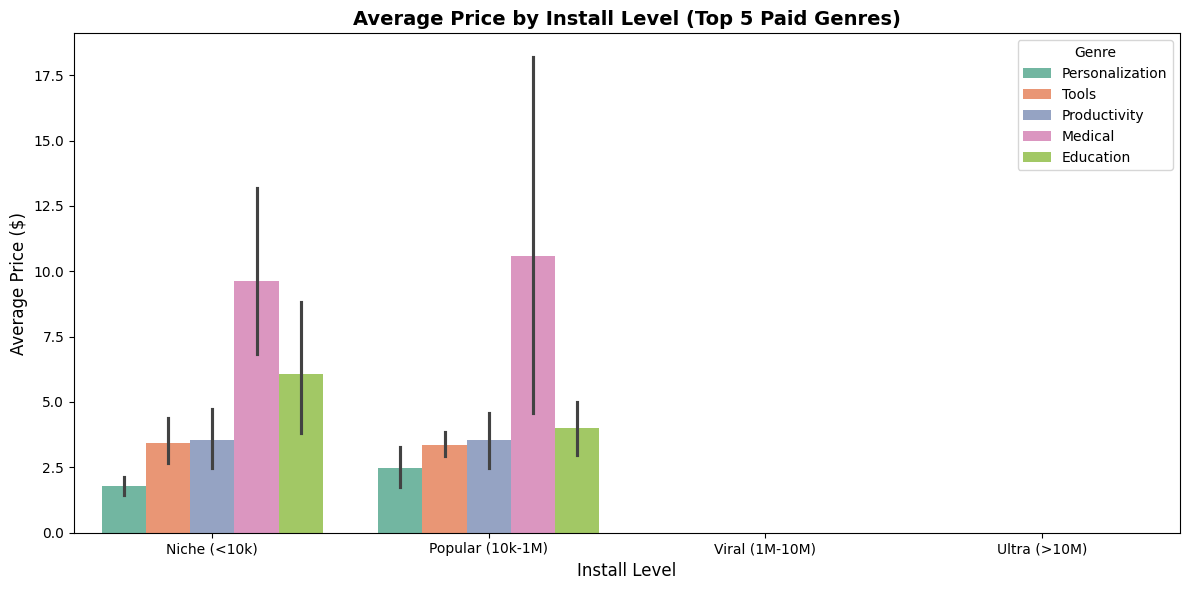

In [2451]:
# Visualization: Average Price by Install Level (Top 5 Paid Genres)
# Purpose: Show how the average price of Paid apps varies across install levels and top genres.
# - Install levels: Specialized (<10k), Popular (10k-1M), Viral (1M-10M), Ultra (>10M)
# - Only the top 5 genres by number of Paid apps are shown

top_5_genres = df_paid['Genres'].value_counts().head(5).index
df_top_5 = df_paid[df_paid['Genres'].isin(top_5_genres)]

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=df_top_5, x='Install_Level', y='Price', hue='Genres', palette='Set2', ax=ax)
ax.set_title('Average Price by Install Level (Top 5 Paid Genres)', fontsize=14, fontweight='bold')
ax.set_xlabel('Install Level', fontsize=12)
ax.set_ylabel('Average Price ($)', fontsize=12)
ax.legend(title='Genre', loc='upper right')

plt.tight_layout()
plt.show()



#### 7. How many apps have a rating higher than 4.7, and what is their average price?

In [2452]:
# Counts how many apps have a high rating above 4.7
df_Rating= df[df["Rating"] > 4.7 ]
len(df_Rating)

867

In [2453]:
# Calculates the average price of apps with a high rating (> 4.7)
avg_price = df_Rating["Price"].mean()
avg_price

np.float64(1.9773356401384088)

In [2454]:
# Analysis:
# 869 apps have a rating above 4.7.
# Their average price is about $2, showing that high-rated apps are the minority and they are usually inexpensive.

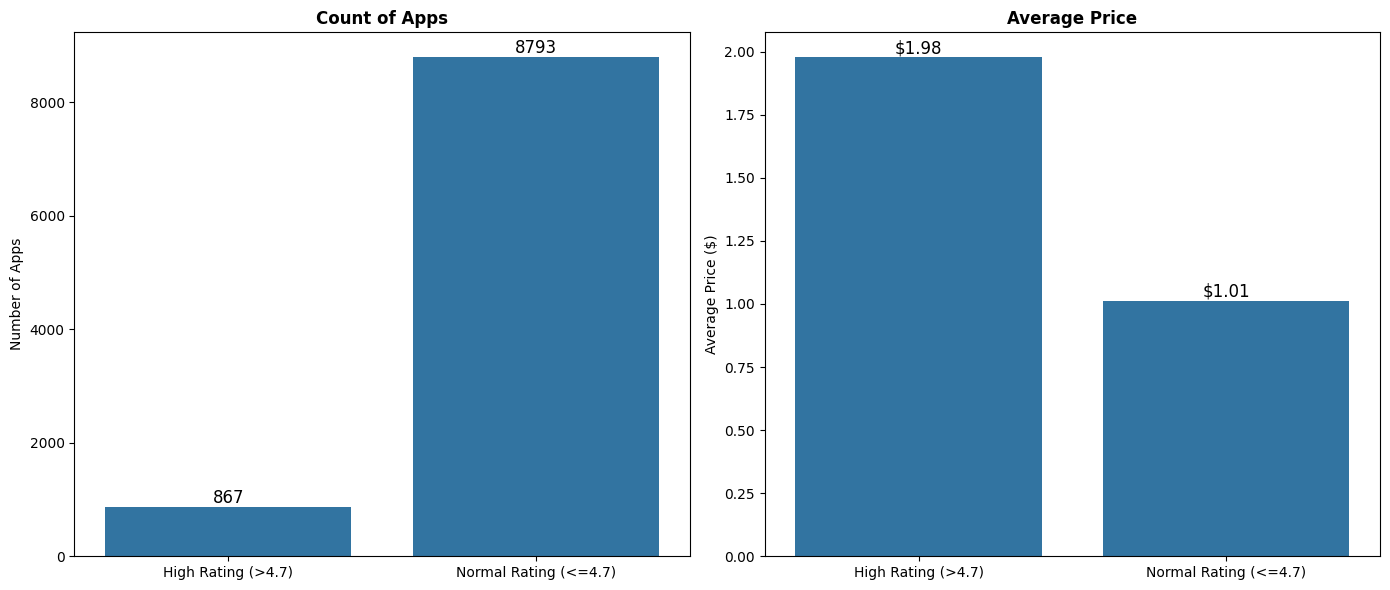

In [2455]:
# Visualization: Apps with High Ratings (>4.7) vs Normal Ratings
# Purpose: Compare the number and average price of apps based on rating.
# - Left plot : count of apps with high vs normal ratings
# - Right plot: average price for each rating group
# - Helps understand if highly rated apps tend to be more expensive

high_rated = df[df['Rating'] > 4.7]
normal_rated = df[df['Rating'] <= 4.7]

counts = [len(high_rated), len(normal_rated)]
labels = ['High Rating (>4.7)', 'Normal Rating (<=4.7)']
avg_prices = [high_rated['Price'].mean(), normal_rated['Price'].mean()]

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(x=labels, y=counts, ax=ax[0])
ax[0].bar_label(ax[0].containers[0], fontsize=12)
ax[0].set_title('Count of Apps', fontweight='bold')
ax[0].set_ylabel('Number of Apps')

sns.barplot(x=labels, y=avg_prices, ax=ax[1])
ax[1].bar_label(ax[1].containers[0], fmt='$%.2f', fontsize=12)
ax[1].set_title('Average Price', fontweight='bold')
ax[1].set_ylabel('Average Price ($)')

plt.tight_layout()
plt.show()

#### 8. What is Google’s estimated revenue from apps with 5,000,000+ installs?
>(Assume Google takes a 30% commission from paid app sales.)

In [2456]:
# Calculates the total estimated revenue of paid apps with at least 5000000 installs
df_paid = df[(df['Type'] == 'Paid') & (df['Installs'] >= 5000000)]
df_paid

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,...,Android Ver,Year_Released,Month_Released,Current_Ver_Cleaned,Android_Ver_Cleaned,Version_Major,Android_Ver_Major,Estimated_Revenue,Is_High_Rated,Install_Level
3295,Hitman Sniper,GAME,4.6,408292,29.0,10000000,Paid,0.99,Mature 17+,Action,...,4.1 and up,2018,7,1.7,4.1,1,4,2970000.0,1,Viral (1M-10M)
5499,Minecraft,FAMILY,4.5,2376564,44.2,10000000,Paid,6.99,Everyone 10+,Arcade;Action & Adventure,...,Varies with device,2018,7,1.5,4.1,1,4,20970000.0,1,Viral (1M-10M)


In [2457]:
total_revenue = df_paid['Estimated_Revenue'].sum()
total_revenue

np.float64(23940000.0)

In [2458]:
# Analysis:
# Google's revenue from Paid apps with ≥5M installs is about $23.94 million.
# Most of this comes from very popular apps like Minecraft.
# Apps with many downloads make most of the revenue, even if their prices are not very high.

#### 9. What are the maximum and minimum sizes of free vs. paid apps?

In [2459]:
# Shows the largest and smallest app sizes for Free and Paid apps
df.groupby("Type")["Size"].agg(['max', 'min'])

,max,min
Type,,
Free,100.0,0.008301
Paid,100.0,0.013672


In [2460]:
# Analysis:
# Both Free and Paid apps reach the same maximum size (100 MB), 
# so file size isn’t determined by payment type.
# Free apps usually have slightly smaller minimum sizes than Paid apps.

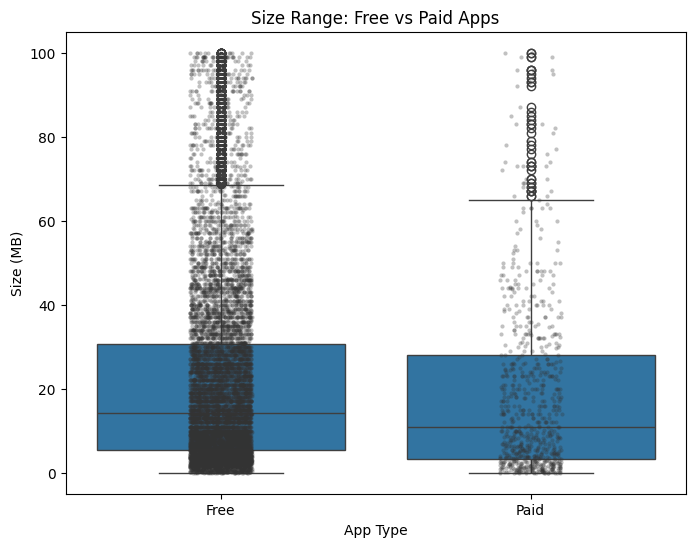

In [2461]:
# Visualization: Maximum and Minimum App Sizes by Type
# Purpose: Compare the size range of Free vs Paid apps.
# - Boxplot shows the distribution of app sizes for each type
# - Stripplot overlays individual data points for more detail
# - Highlights max and min sizes and overall variation in app size
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(x='Type', y='Size', data=df, ax=ax)
sns.stripplot(x='Type', y='Size', data=df, color='#333', alpha=0.3, size=3, ax=ax)
ax.set_title('Size Range: Free vs Paid Apps')
ax.set_xlabel('App Type')
ax.set_ylabel('Size (MB)')
plt.show()

#### 10. Is there a correlation between rating, number of reviews, size, and price?

In [2462]:
# Calculate the correlation matrix for the specified columns
corr_cols = ['Rating', 'Reviews', 'Size', 'Price']
correlation_matrix = df[corr_cols].corr()
# Display the matrix values
correlation_matrix

,Rating,Reviews,Size,Price
Rating,1.000000,0.049879,0.068652,-0.004970
Reviews,0.049879,1.000000,0.147754,-0.007597
Size,0.068652,0.147754,1.000000,-0.024622
Price,-0.004970,-0.007597,-0.024622,1.000000


In [2463]:
# Analysis:
# Ratings have very weak correlation with Price and Size.
# This means higher price or larger app doesn't guarantee a better rating.
# Reviews show a slight positive correlation with Rating, but not strong.
# Overall, the strongest link is Size vs Reviews (0.15), 
# meaning bigger apps (like games) tend to get more user interaction.

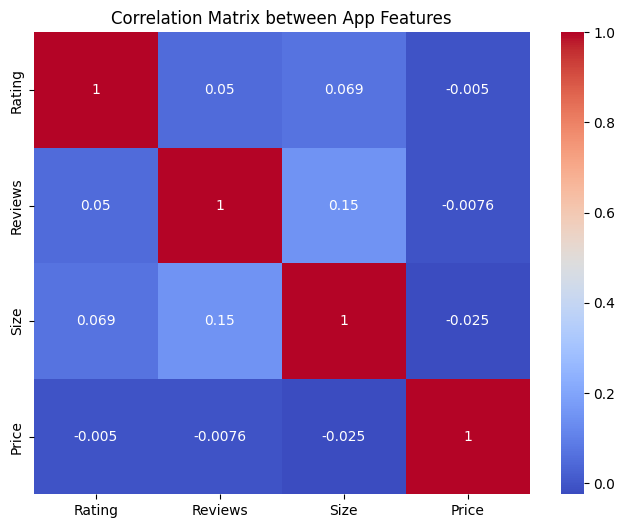

In [2464]:
# Visualization: Correlation between app features
# Purpose: Show relationships between Rating, Number of Reviews, Size, and Price.
# - correlation_matrix contains correlation values between these features
# - Heatmap displays how strongly each feature is related to the others
# - Helps identify which features might influence each other
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', ax=ax)
ax.set_title('Correlation Matrix between App Features')
plt.show()


#### 11. How many apps exist for each type (Free/Paid) across different content ratings?

In [2465]:
# Count the frequency of each combination of Type and Content Rating
df[['Type', 'Content Rating']].value_counts()

Type  Content Rating
Free  Everyone          7251
      Teen               984
Paid  Everyone           655
Free  Mature 17+         378
      Everyone 10+       291
Paid  Teen                52
      Everyone 10+        31
      Mature 17+          18
Name: count, dtype: int64

In [2466]:
# Analysis:
# Most apps are rated "Everyone".
# For "Teen" and "Adult" ratings, Free apps are more common.
# This is likely because teenagers often don't have credit cards,
# so developers release free apps for them.
# Paid apps are mostly targeted at the "Everyone" category.

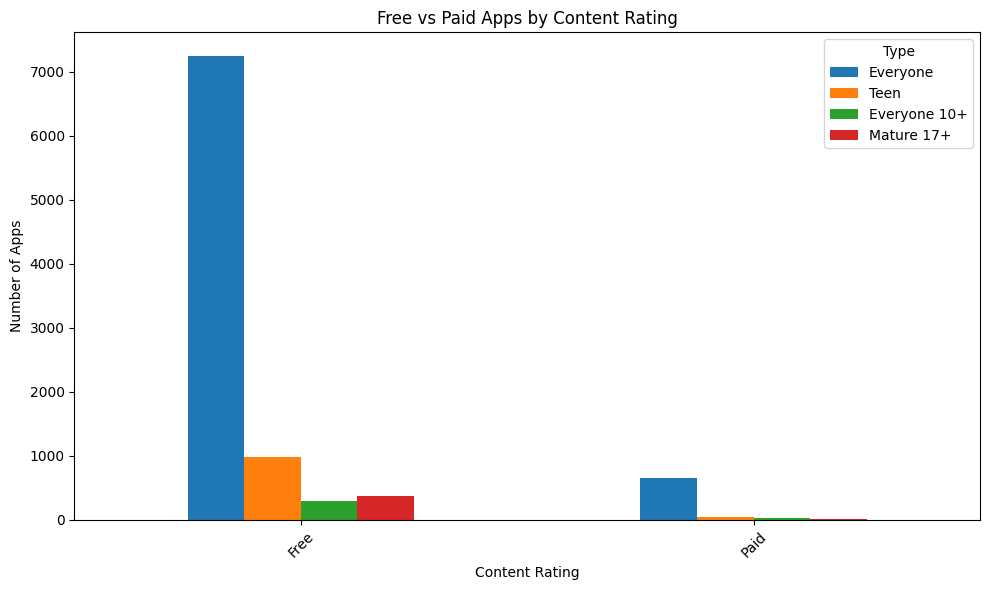

In [2467]:
# Visualization: Number of Free vs Paid Apps by Content Rating
# Purpose: Show how many apps are Free or Paid across different content ratings.
# type_rating_counts counts apps by Type and Content Rating
type_rating_counts = df[['Type', 'Content Rating']].value_counts()
plot_data = type_rating_counts.unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(10, 6))
plot_data.plot(kind='bar', ax=ax)
ax.set_title('Free vs Paid Apps by Content Rating')
ax.set_xlabel('Content Rating')
ax.set_ylabel('Number of Apps')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.legend(title='Type')
plt.tight_layout()
plt.show()

#### 12. How many apps are compatible with Android version 4.x?

In [2468]:
# Use the new numeric column for precise filtering
df_android_4x = df[df['Android_Ver_Major'] == 4]
# Count the number of apps having android version with 4.x
len(df_android_4x)

7273

In [2469]:
# Analysis:
# Most apps are compatible with Android 4.x.
# This indicates that Android 4.x was the most popular and widely targeted version for developers.

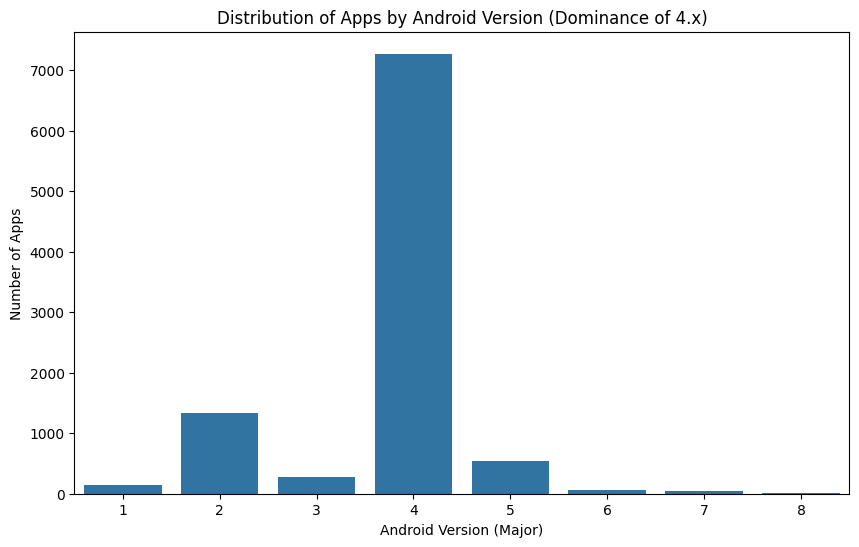

In [2470]:
# Visualization: Number of Apps per Android Version
# Purpose: Show how many apps are compatible with each major Android version.
# - android_counts counts apps for each major version
android_counts = df['Android_Ver_Major'].value_counts().sort_index() 
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=android_counts.index, y=android_counts.values, ax=ax)
ax.set_title('Distribution of Apps by Android Version (Dominance of 4.x)')
ax.set_xlabel('Android Version (Major)')
ax.set_ylabel('Number of Apps')
plt.show()

## Aditional Questions:

#### 13. How has the number of app updates changed over the years?

In [2471]:
# Analysis:
# This plot shows how app development and updates have changed over the years.
# The number of apps and updates generally increased from early years (2010) to 2018.
# The peak year shows the highest developer activity.

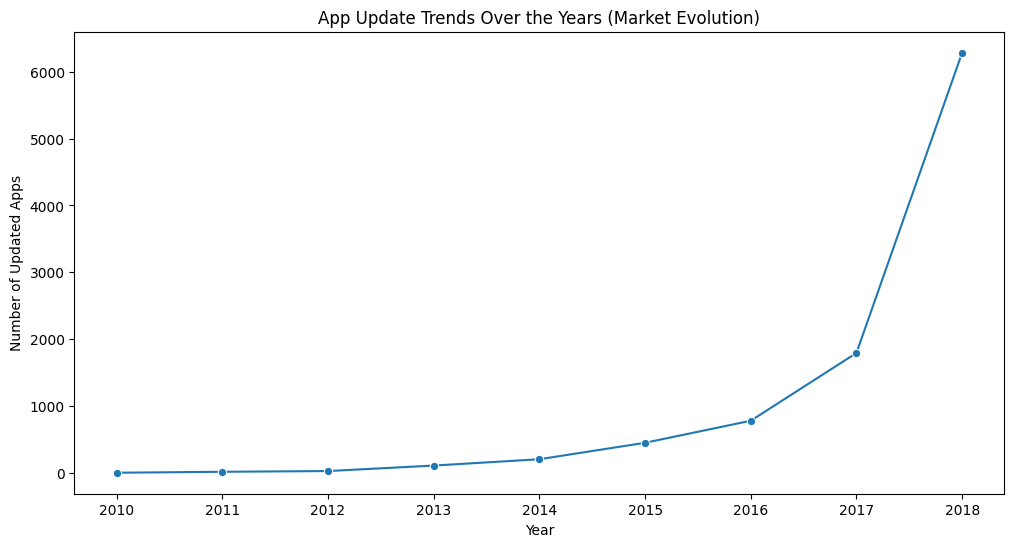

In [2472]:
# Visualization: Number of App Updates Over the Years
# Purpose: Show how the number of app updates has changed over time.
# year_counts counts how many apps were updated each year
year_counts = df['Year_Released'].value_counts().sort_index()
plt.figure(figsize=(12, 6))
sns.lineplot(x=year_counts.index, y=year_counts.values, marker='o')
plt.title('App Update Trends Over the Years (Market Evolution)')
plt.xlabel('Year')
plt.ylabel('Number of Updated Apps')
plt.show()

#### 14. How does the average app size vary by install level?

In [2473]:
# Analysis:
# This analysis looks at how an app's popularity (install count) relates to its file size.
# We group apps into: Specialized, Popular, Viral, and Ultra.
# The plot usually shows that more popular apps tend to be bigger,
# because apps with many installs often have more features, media, and storage needs.

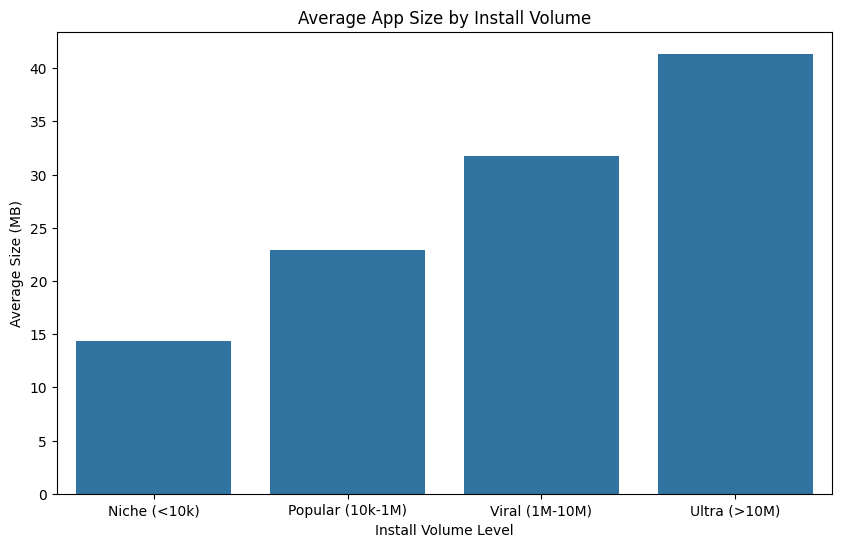

In [2474]:
# Visualization: Average App Size by Install Level
# Purpose: Show how app size changes with number of installs.
# - Specialized (<10k)    --> few installs, small audience
# - Popular     (10k-1M)  --> medium installs, medium audience
# - Viral       (1M-10M)  --> many installs, large audience
# - Ultra       (>10M)    --> extremely many installs, very large audience

fig, ax = plt.subplots(figsize=(10, 6))
avg_size_by_installs = df.groupby('Install_Level')['Size'].mean()
sns.barplot(x=avg_size_by_installs.index, y=avg_size_by_installs.values, ax=ax)
ax.set_title('Average App Size by Install Volume')
ax.set_ylabel('Average Size (MB)')
ax.set_xlabel('Install Volume Level')
plt.show()

#### 15. How does the average app price vary by install level?

In [2475]:
# Analysis:
# This plot shows how app popularity (install volume) relates to price.
# Popular apps (Viral/Ultra) tend to be cheaper or free to reach more users,
# while specialized apps (few installs) usually charge higher prices for Specialized services.

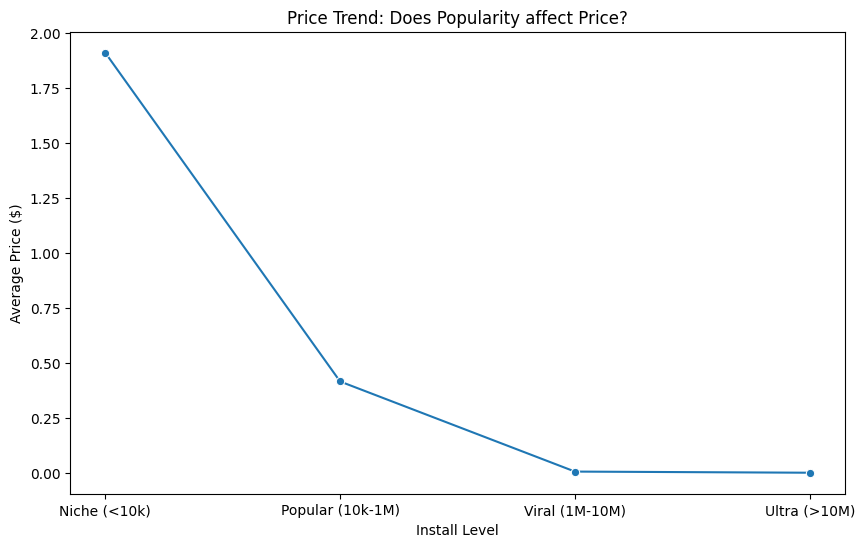

In [2476]:
# Visualization: Avg App Price vs Install Level 
# Purpose: Show how app price changes with the number of installs.
# - Specialized (<10k)   --> few installs, small audience
# - Popular     (10k-1M) --> medium installs, medium audience
# - Viral       (1M-10M) --> many installs, large audience
# - Ultra       (>10M)   --> extremely many installs, very large audience

avg_price_trend = df.groupby('Install_Level')['Price'].mean()
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(x=avg_price_trend.index,y=avg_price_trend.values,marker='o',ax=ax)
ax.set_title('Price Trend: Does Popularity affect Price?')
ax.set_xlabel('Install Level')
ax.set_ylabel('Average Price ($)')
plt.show()

#### 16. How does the average app rating vary by install level?

In [2477]:
#Analysis:
# This analysis investigates the relationship between app popularity and user satisfaction.
# By grouping apps by install level (specialized, Popular, Viral), we can observe that Apps with higher install levels generally receive higher and more consistent ratings,
# whereas specialized apps exhibit wider variability and more low-rating outliers.

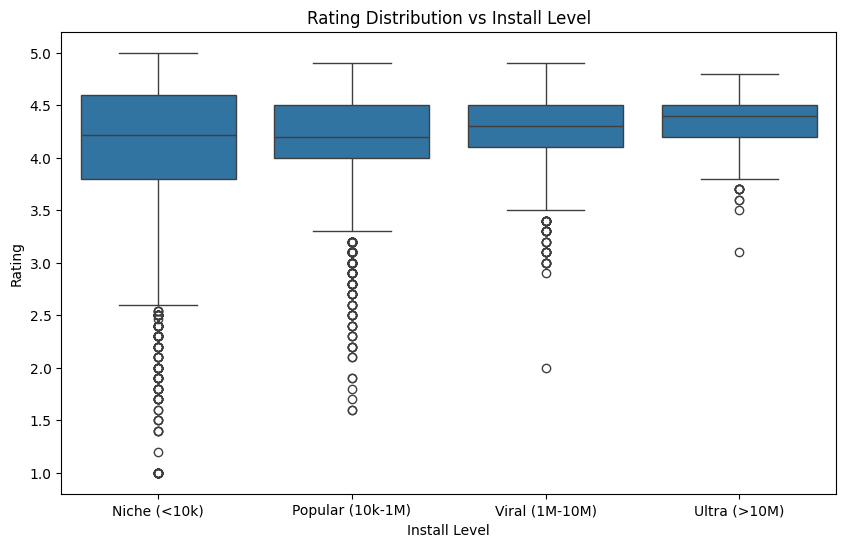

In [2478]:
# Visualization: App Rating vs Install Level
# Purpose: Show how app ratings vary with install volume.
# - Specialized (<10k)   --> few installs, small audience
# - Popular     (10k-1M) --> medium installs, medium audience
# - Viral       (1M-10M) --> many installs, large audience
# - Ultra       (>10M)   --> extremely many installs, very large audience

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df, x='Install_Level', y='Rating', ax=ax)
ax.set_title('Rating Distribution vs Install Level')
ax.set_xlabel('Install Level')
ax.set_ylabel('Rating')
plt.show()

# **Phase 5: Data Preparation for Modeling**

In this phase, i will prepare the dataset for machine learning.  

**What was done:**
- **Encoding:** Converted categorical text (`Category`, `Genres`, `Type`) into numerical values using **Label Encoding** and **One-Hot Encoding**.  
- **Scaling:** Applied **StandardScaler** and **RobustScaler** to normalize numerical features so they are on the same scale.  
- **Train-Test Split:** Divided the data into **Training (80%)** and **Testing (20%)** sets to evaluate model performance properly.

In [2479]:
# Make a copy of the original DataFrame to work on, preserving the original data
df_model = df.copy()
df_model.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver', 'Year_Released', 'Month_Released', 'Current_Ver_Cleaned',
       'Android_Ver_Cleaned', 'Version_Major', 'Android_Ver_Major',
       'Estimated_Revenue', 'Is_High_Rated', 'Install_Level'],
      dtype='str')

### **Step 1: Defining Target and Features**

#### **Defining the Target Variable (y)**
We select the `Is_High_Rated` column as the target variable (y) for the ML model.

- **Prediction Objective:** Predict user satisfaction or app quality based on other features.  
- **Exclusion from Features (X):** Removing the target from X prevents **Data Leakage** and ensures valid predictions.

#### **Drop Unnecessary Columns for Feature Set (X)**
We remove columns that are irrelevant or could harm model training:

1. **`App`**          – Unique identifier, not useful for prediction.  
2. **`Last Updated`** – Textual date, replaced with numerical features like Year/Month.  
3. **`Current Ver`**&**`Current_Ver_Cleaned`**  – Text version, replaced with numeric column `Version_Major`
4. **`Android Ver`**&**`Android_Ver_Cleaned`**  – Text version, replaced with numeric column `Android_Ver_Major`. 'Rating',          # The 
5. **`Rating`**       – dropped to prevent Data Leakage (perfect correlation with the binary target)
6. **`Is_High_Rated`**       – Target variable; should not be part of X (will be dropped in the splitting step)




In [2480]:
cols_to_drop = [
    'App',            
    'Last Updated',    
    'Current Ver',     
    'Android Ver',   
    'Current_Ver_Cleaned',
    'Android_Ver_Cleaned',
    'Rating',
    'Install_Level'
]

# Drop these columns to create the feature set
df_model.drop(columns=cols_to_drop, inplace=True)

### **Step 2: Encoding Categorical Features**  

#### **One-Hot Encoding (Few Categories)**
- Columns: `Type`, `Content Rating`  
- Converts categorical text into binary columns (0/1)  
- `drop_first=True` removes one category per column to avoid redundancy  

#### **Label Encoding (Many Categories)**
- Columns: `Category`, `Genres`  
- Converts text into numeric labels (0, 1, 2, …)  
- Original text columns are deleted automatically  

Note:
Categories like Category and Genres are just names with no natural ranking. We still used Label Encoding because using One-Hot Encoding would create hundreds of new columns, making the data too large and complex.

In [2481]:
df_model.columns

Index(['Category', 'Reviews', 'Size', 'Installs', 'Type', 'Price',
       'Content Rating', 'Genres', 'Year_Released', 'Month_Released',
       'Version_Major', 'Android_Ver_Major', 'Estimated_Revenue',
       'Is_High_Rated'],
      dtype='str')

In [2482]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# 1. Columns with few categories --> One-Hot Encoding
few_categories = ['Type', 'Content Rating']
df_model = pd.get_dummies(df_model, columns=few_categories, drop_first=True)
# drop_first=True removes one category from each column to avoid redundancy

# 2. Columns with many categories--> Label Encoding
many_categories = ['Category', 'Genres']
le = LabelEncoder()
for col in many_categories:
    df_model[col] = le.fit_transform(df_model[col])
    
# Show all columns after encoding
# note the original columns are deleated ['Category', 'Type', 'Content Rating', 'Genres']
df_model.columns

Index(['Category', 'Reviews', 'Size', 'Installs', 'Price', 'Genres',
       'Year_Released', 'Month_Released', 'Version_Major', 'Android_Ver_Major',
       'Estimated_Revenue', 'Is_High_Rated', 'Type_Paid',
       'Content Rating_Everyone 10+', 'Content Rating_Mature 17+',
       'Content Rating_Teen'],
      dtype='str')

In [2483]:
df_model

,Category,Reviews,Size,Installs,Price,Genres,Year_Released,Month_Released,Version_Major,Android_Ver_Major,Estimated_Revenue,Is_High_Rated,Type_Paid,Content Rating_Everyone 10+,Content Rating_Mature 17+,Content Rating_Teen
0,28,9992,31.000000,1000000,0.00,99,2018,5,6,4,0.000,1,False,False,False,False
1,29,999,0.088867,100000,0.00,105,2013,12,3,2,0.000,0,False,False,False,False
2,26,9975,18.000000,1000000,0.00,93,2018,1,1,4,0.000,1,False,False,False,False
3,28,9971,33.000000,1000000,0.00,99,2018,6,7,5,0.000,1,False,False,False,False
4,30,9971,22.000000,500000,0.00,107,2018,8,1,5,0.000,1,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9655,11,0,16.000000,100,0.00,39,2016,6,1,4,0.000,0,False,False,False,False
9656,3,0,8.000000,100,0.00,19,2017,7,1,4,0.000,0,False,False,False,False
9657,17,0,2.600000,100,0.00,63,2017,12,1,4,0.000,0,False,False,False,False
9658,23,0,11.000000,5,0.99,77,2016,8,1,4,1.485,0,True,False,False,False


### **Step 3: Train-Test Split**

We split the dataset into training and testing sets.

- **Split Ratio:** Use an appropriate split, 80% training and 20% testing.  
- **Random State:** Set a `random_state` to ensure reproducibility of results.  
- **Target Variable:** Clearly define the target variable (y) for the split.

> This ensures the model is tested on **unseen data** for a more accurate estimate of its performance.

In [2484]:
# split the dataset into training and testing sets (80% train, 20% test)
# X contains features, y contains the target variable T=Rating
from sklearn.model_selection import train_test_split
X = df_model.drop("Is_High_Rated", axis=1)
y = df_model["Is_High_Rated"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2 , random_state=42)

### **Step 4: Scaling**

**Feature Scaling Approach:**

- For `Year_Released`, `Month_Released` as there are no obvious outliers and the distributions seem relatively balanced, **StandardScaler** is applied to normalize values (mean = 0, variance = 1).

- For `Size`, `Installs`, `Reviews`, `Price`, `Estimated_Revenue`, due to heavily skewed distributions and the presence of outliers, **RobustScaler** is used.  
  This scaler relies on the median and IQR, making it more resistant to extreme values.

---

### **Notes**

- **No scaling for Version features (`Version_Major`, `Android_Ver_Major`):**  
  These represent ordinal information (e.g., version 4 > version 3), and scaling is not necessary as the numeric meaning is already meaningful and not affected by magnitude differences.

- **No scaling for encoded categorical features:**  
  Columns that were transformed using **One-Hot Encoding** or **Label Encoding** represent categories, not continuous values.  
  Scaling them would distort their meaning and is therefore avoided.

In [2485]:
from sklearn.preprocessing import StandardScaler
numeric_cols = ['Year_Released', 'Month_Released'] 
# Initialize StandardScaler
scaler = StandardScaler()
# fit the scaler on training data and transform the training set
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
# transform the test set using the same scaler
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [2486]:
from sklearn.preprocessing import RobustScaler
numeric_cols = ['Size', 'Installs', 'Reviews', 'Price' , 'Estimated_Revenue'] 
# Initialize RobustScaler
scaler = RobustScaler(quantile_range=(25.0, 75.0))  # Uses median and IQR to scale values
# Scale the 'Diff' column 
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols]  = scaler.transform(X_test[numeric_cols])

In [2487]:
df_model

,Category,Reviews,Size,Installs,Price,Genres,Year_Released,Month_Released,Version_Major,Android_Ver_Major,Estimated_Revenue,Is_High_Rated,Type_Paid,Content Rating_Everyone 10+,Content Rating_Mature 17+,Content Rating_Teen
0,28,9992,31.000000,1000000,0.00,99,2018,5,6,4,0.000,1,False,False,False,False
1,29,999,0.088867,100000,0.00,105,2013,12,3,2,0.000,0,False,False,False,False
2,26,9975,18.000000,1000000,0.00,93,2018,1,1,4,0.000,1,False,False,False,False
3,28,9971,33.000000,1000000,0.00,99,2018,6,7,5,0.000,1,False,False,False,False
4,30,9971,22.000000,500000,0.00,107,2018,8,1,5,0.000,1,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9655,11,0,16.000000,100,0.00,39,2016,6,1,4,0.000,0,False,False,False,False
9656,3,0,8.000000,100,0.00,19,2017,7,1,4,0.000,0,False,False,False,False
9657,17,0,2.600000,100,0.00,63,2017,12,1,4,0.000,0,False,False,False,False
9658,23,0,11.000000,5,0.99,77,2016,8,1,4,1.485,0,True,False,False,False


### **Step 4: dealing with Imbalanced Classes**

- many datasets have imbalanced target classes
- SMOTE creates samples for the minority class to balance the dataset.
- apply SMOTE only on the training set to avoid data leakage.
- after SMOTE, the training data has balanced classes, which helps the model learn better.

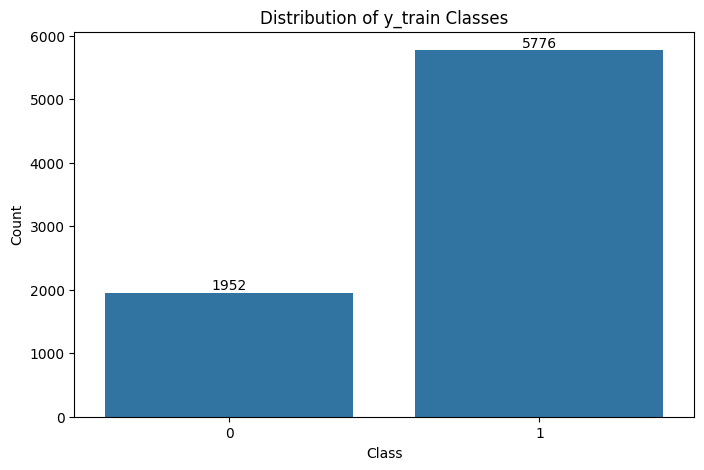

In [2488]:
# Visualization: Original Class Distribution (Imbalance Check)
# Purpose: Show the distribution of classes in y_train before applying SMOTE to identify class imbalance.
counts = y_train.value_counts().sort_index() 
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=counts.index, y=counts.values, ax=ax)
ax.bar_label(ax.containers[0])
ax.set_title('Distribution of y_train Classes')
ax.set_xlabel('Class')
ax.set_ylabel('Count')
plt.show()

In [2489]:
from imblearn.over_sampling import SMOTE
x = df_model.drop('Is_High_Rated' , axis= 1)
y = df_model['Is_High_Rated']
# initialize SMOTE 
smote = SMOTE()
# fit SMOTE on the training data and resample
X_train, y_train = smote.fit_resample(X_train, y_train)

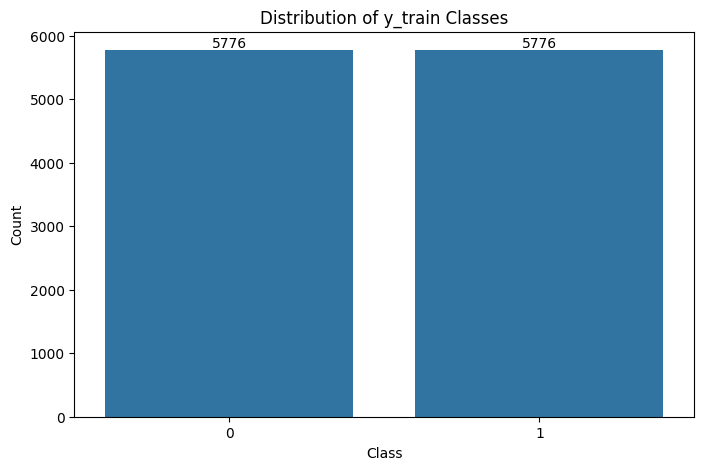

In [2490]:
# Visualization: Class Distribution After SMOTE
# Purpose: Validate the effect of SMOTE by showing that the minority class has been
# synthetically increased to balance the dataset and reduce model bias.
counts = y_train.value_counts().sort_index() 
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=counts.index, y=counts.values, ax=ax)
ax.bar_label(ax.containers[0])
ax.set_title('Distribution of y_train Classes')
ax.set_xlabel('Class')
ax.set_ylabel('Count')
plt.show()

In [2491]:
cols_to_convert = ['Type_Paid', 'Content Rating_Everyone 10+', 
                   'Content Rating_Mature 17+', 'Content Rating_Teen']

df_model[cols_to_convert] = df_model[cols_to_convert].astype(int)

In [2492]:
df_model

,Category,Reviews,Size,Installs,Price,Genres,Year_Released,Month_Released,Version_Major,Android_Ver_Major,Estimated_Revenue,Is_High_Rated,Type_Paid,Content Rating_Everyone 10+,Content Rating_Mature 17+,Content Rating_Teen
0,28,9992,31.000000,1000000,0.00,99,2018,5,6,4,0.000,1,0,0,0,0
1,29,999,0.088867,100000,0.00,105,2013,12,3,2,0.000,0,0,0,0,0
2,26,9975,18.000000,1000000,0.00,93,2018,1,1,4,0.000,1,0,0,0,0
3,28,9971,33.000000,1000000,0.00,99,2018,6,7,5,0.000,1,0,0,0,0
4,30,9971,22.000000,500000,0.00,107,2018,8,1,5,0.000,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9655,11,0,16.000000,100,0.00,39,2016,6,1,4,0.000,0,0,0,0,0
9656,3,0,8.000000,100,0.00,19,2017,7,1,4,0.000,0,0,0,0,0
9657,17,0,2.600000,100,0.00,63,2017,12,1,4,0.000,0,0,0,0,0
9658,23,0,11.000000,5,0.99,77,2016,8,1,4,1.485,0,1,0,0,0
